In [12]:
# ============================================================
# HealthConnect - Week 5
# Data Science Track
# ============================================================

# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Bibliothèques importées")

✅ Bibliothèques importées


In [13]:
# Charger les données
df = pd.read_csv('HealthConnect_Appointment_Data.csv')

print(f"📊 Shape: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\n🔍 Aperçu:")
display(df.head())

📊 Shape: 5000 lignes, 18 colonnes

🔍 Aperçu:


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [14]:
print("\n📋 Types de données:")
print(df.dtypes)

print("\n📊 Statistiques:")
display(df.describe(include='all'))

print("\n🔍 Valeurs manquantes:")
print(df.isnull().sum())


📋 Types de données:
appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
dtype: object

📊 Statistiques:


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
count,5000,5000,5000,5000.000000,5000,5000,5000,5000,5000,5000,5000.00000,5000.000000,5000.000000,5000,3634,4910.000000,4940.000000,5000
unique,5000,1696,3,NaN,6,4,593,545,7,3,NaN,NaN,NaN,2,3,NaN,NaN,3
top,HC-05000,P-1742,Female,NaN,65+,General Consultation,8/24/2025,3/14/2026,Wednesday,Morning,NaN,NaN,NaN,Yes,SMS,NaN,NaN,No-Show
freq,1,9,2488,NaN,1241,2086,20,18,737,2227,NaN,NaN,NaN,3634,2000,NaN,NaN,2423
mean,NaN,NaN,NaN,48.794800,NaN,NaN,NaN,NaN,NaN,NaN,29.63860,3.013800,0.544200,NaN,NaN,10.109572,24.189676,NaN
std,NaN,NaN,NaN,18.138547,NaN,NaN,NaN,NaN,NaN,NaN,17.39936,1.741211,0.746832,NaN,NaN,6.590030,10.863184,NaN
min,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,0.000000,0.000000,NaN,NaN,0.500000,2.000000,NaN
25%,NaN,NaN,NaN,33.000000,NaN,NaN,NaN,NaN,NaN,NaN,15.00000,2.000000,0.000000,NaN,NaN,5.300000,17.000000,NaN
50%,NaN,NaN,NaN,49.000000,NaN,NaN,NaN,NaN,NaN,NaN,30.00000,3.000000,0.000000,NaN,NaN,8.700000,24.000000,NaN
75%,NaN,NaN,NaN,64.000000,NaN,NaN,NaN,NaN,NaN,NaN,45.00000,4.000000,1.000000,NaN,NaN,13.500000,32.000000,NaN



🔍 Valeurs manquantes:
appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64



DISTRIBUTION DE LA VARIABLE CIBLE

📊 Nombre de rendez-vous par outcome:
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

📊 Pourcentage par outcome:
appointment_outcome
No-Show      48.5
Attended     46.3
Cancelled     5.3
Name: proportion, dtype: float64


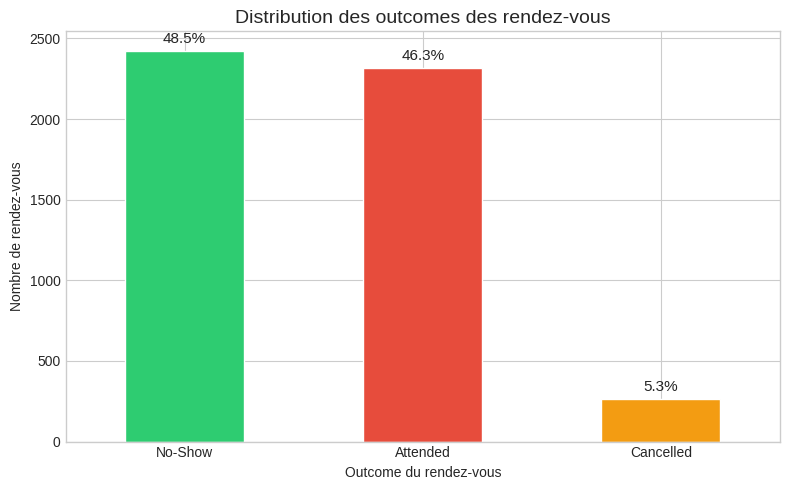


STATISTIQUES DES VARIABLES NUMÉRIQUES

📊 Colonnes numériques disponibles: ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'waiting_time_minutes']


,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,29.63860,3.013800,0.544200,10.109572,24.189676
std,18.138547,17.39936,1.741211,0.746832,6.590030,10.863184
min,18.000000,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,60.00000,11.000000,5.000000,45.000000,68.000000


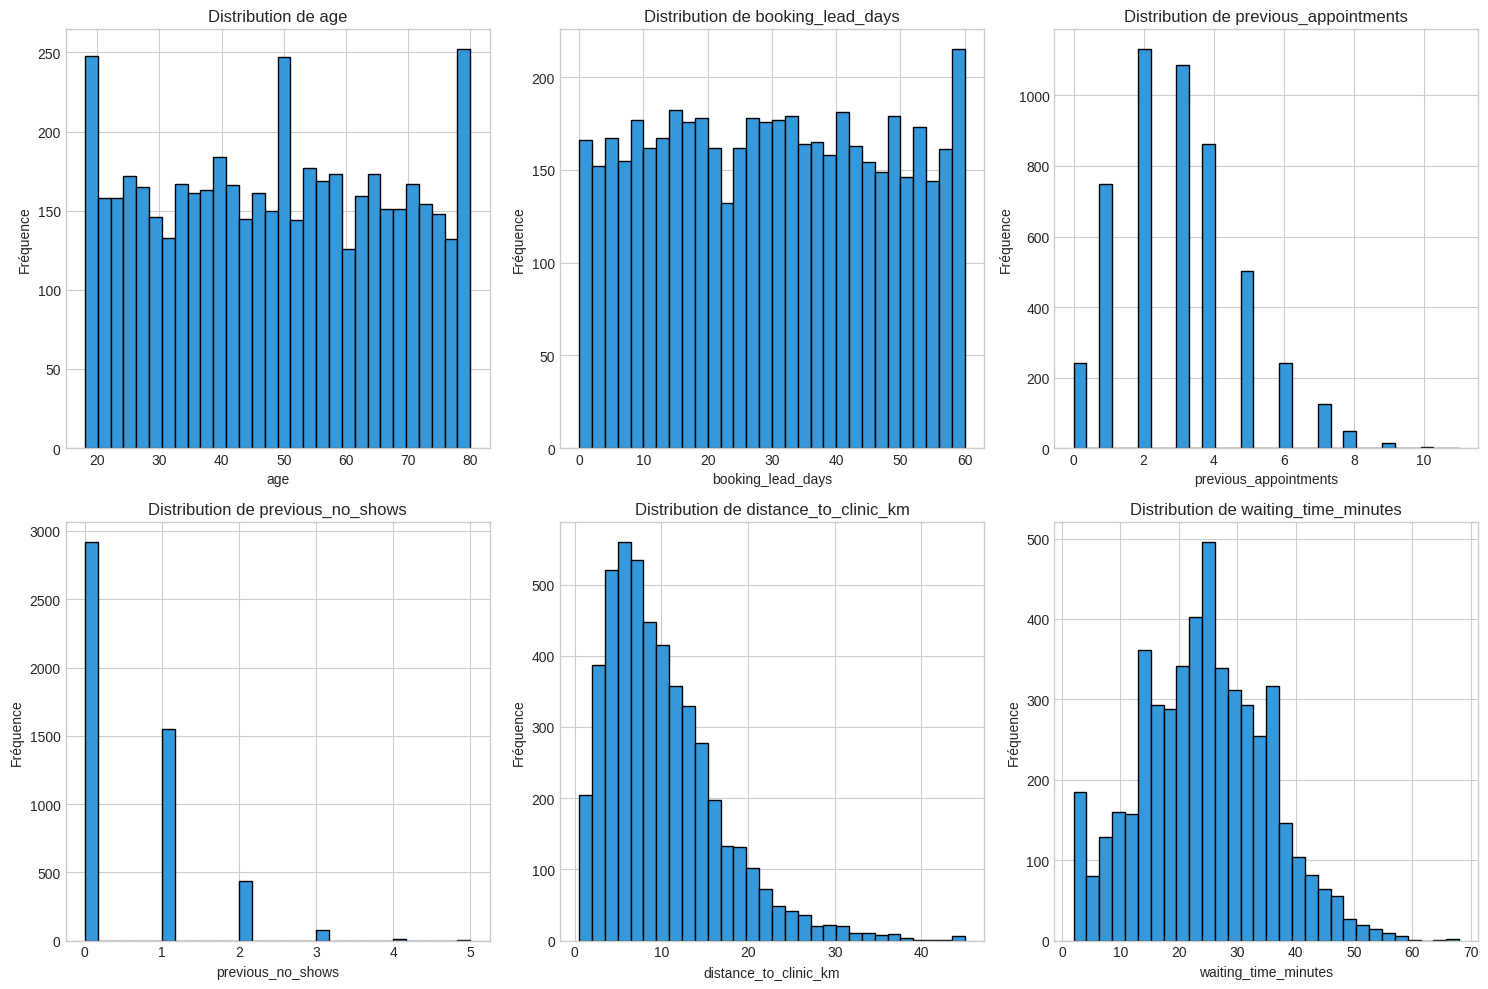


ANALYSE DES VARIABLES CATÉGORIELLES

📊 Colonnes catégorielles: ['appointment_id', 'patient_id', 'gender', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel', 'appointment_outcome']

🔍 appointment_id:
   - Valeurs uniques: 5000
   - Top 5: {'HC-05000': 1, 'HC-00001': 1, 'HC-00002': 1, 'HC-00003': 1, 'HC-00004': 1}

🔍 patient_id:
   - Valeurs uniques: 1696
   - Top 5: {'P-1742': 9, 'P-1399': 9, 'P-1776': 9, 'P-0252': 8, 'P-0869': 8}

🔍 gender:
   - Valeurs uniques: 3
   - Top 5: {'Female': 2488, 'Male': 2404, 'Prefer not to say': 108}

🔍 age_group:
   - Valeurs uniques: 6
   - Top 5: {'65+': 1241, '35-44': 819, '55-64': 800, '45-54': 793, '25-34': 783}

🔍 appointment_type:
   - Valeurs uniques: 4
   - Top 5: {'General Consultation': 2086, 'Follow-up': 1421, 'Specialist Consultation': 900, 'Diagnostic Test': 593}

🔍 booking_date:
   - Valeurs uniques: 593
   - Top 5: {'8/24/2025': 20, '1/26/2026'

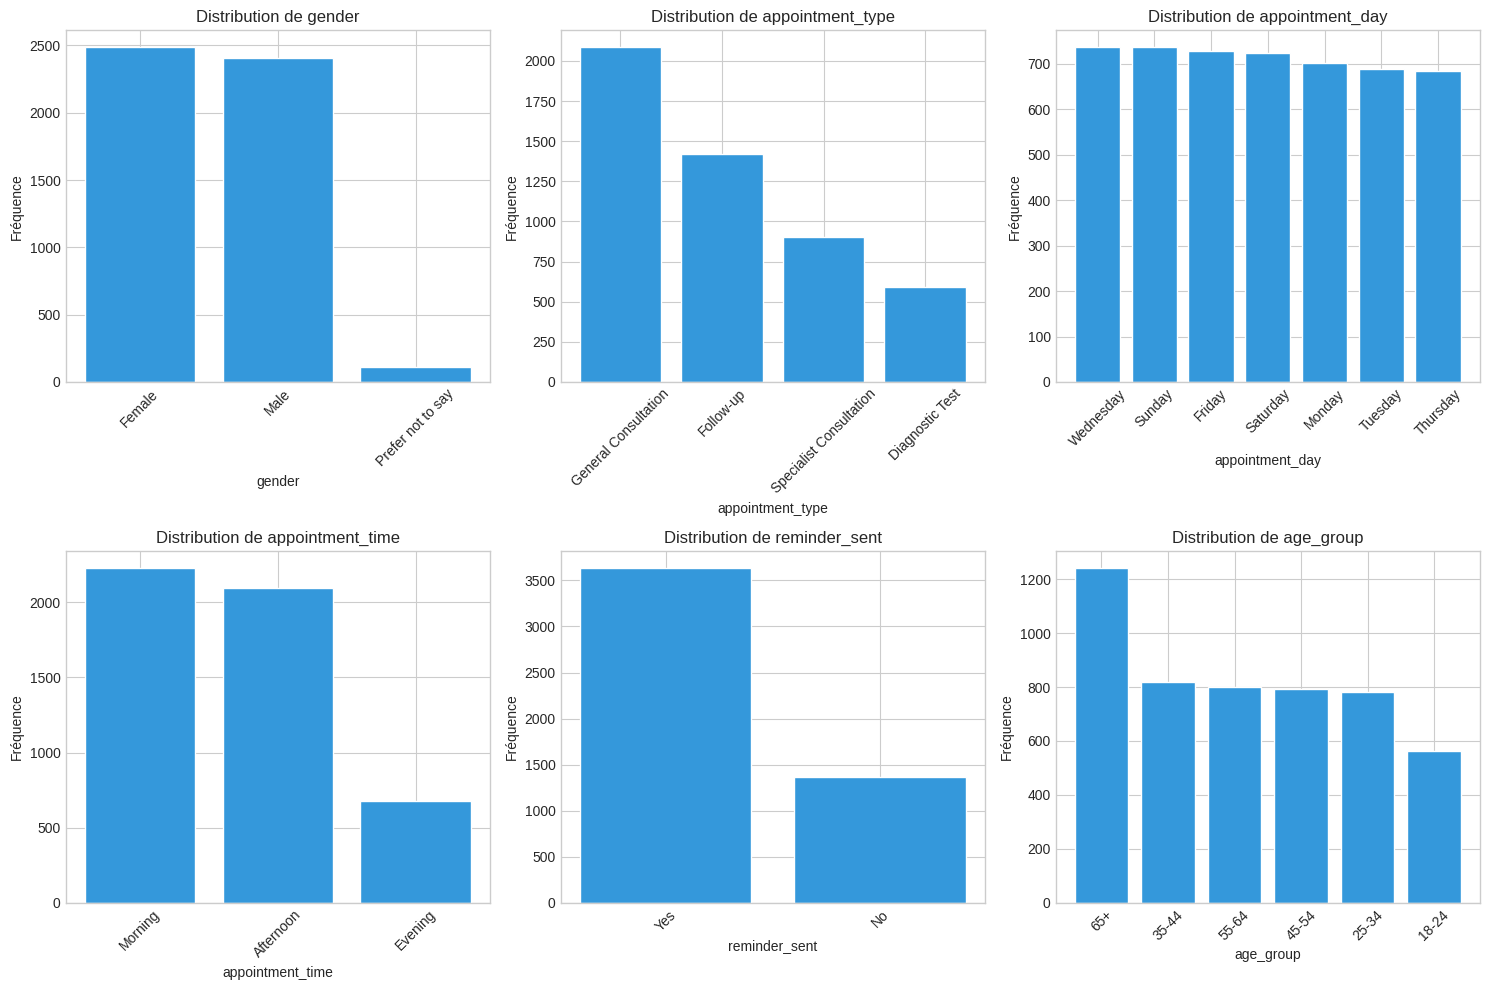


RELATION AVEC LA VARIABLE CIBLE


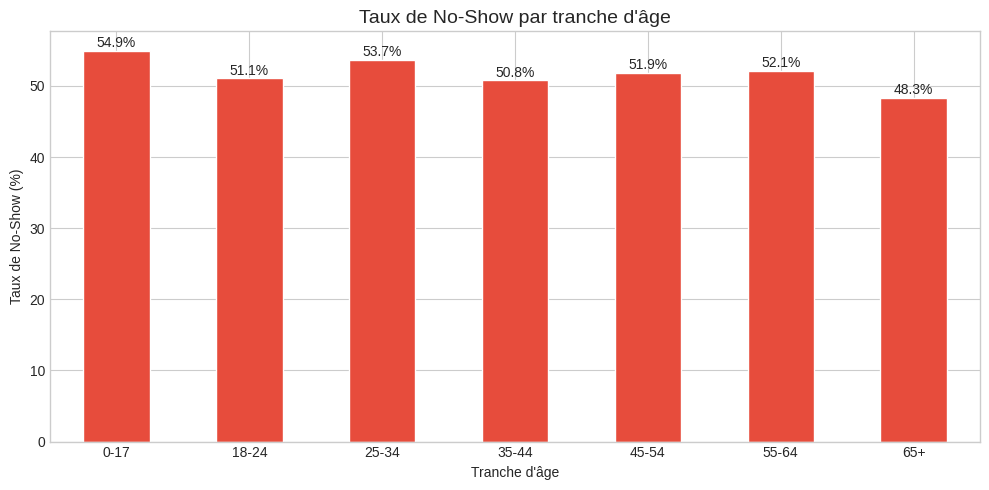

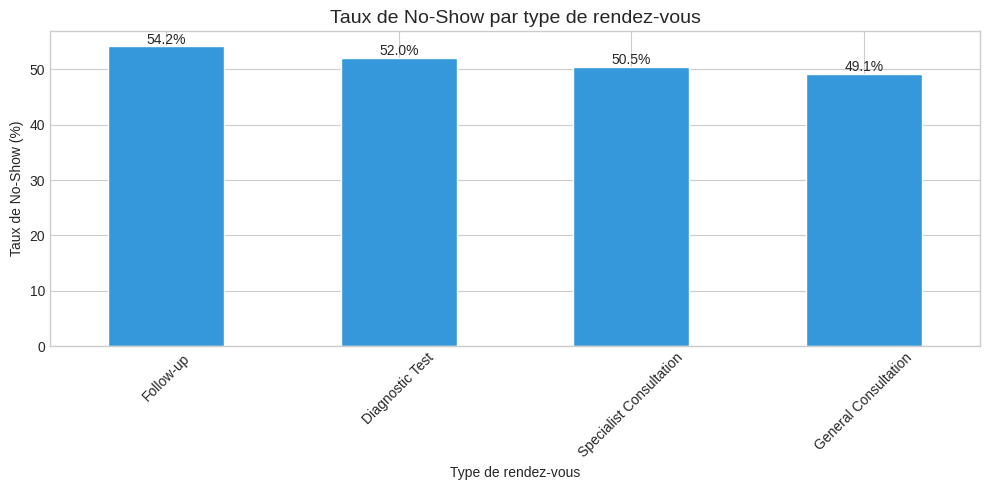

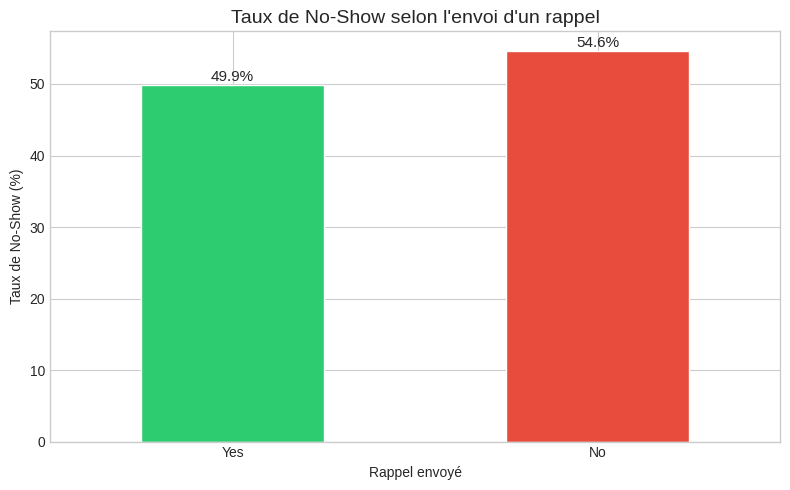

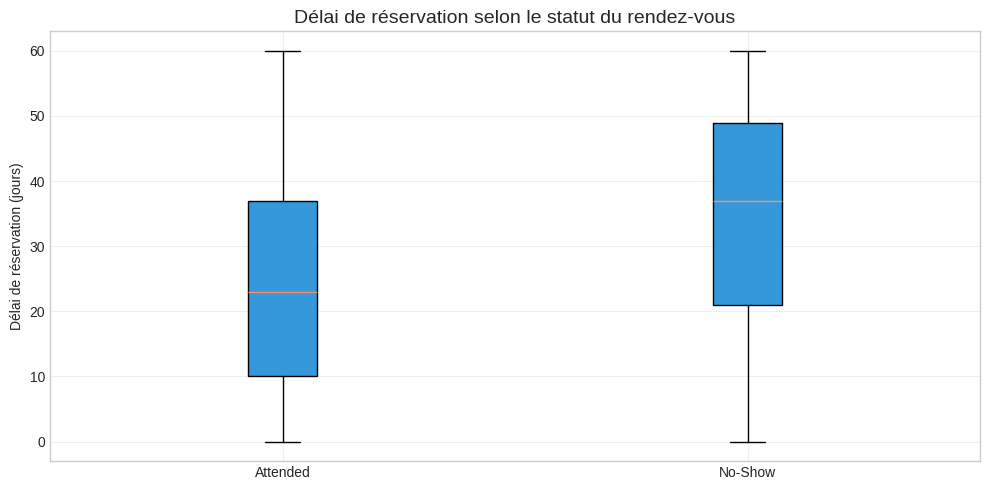

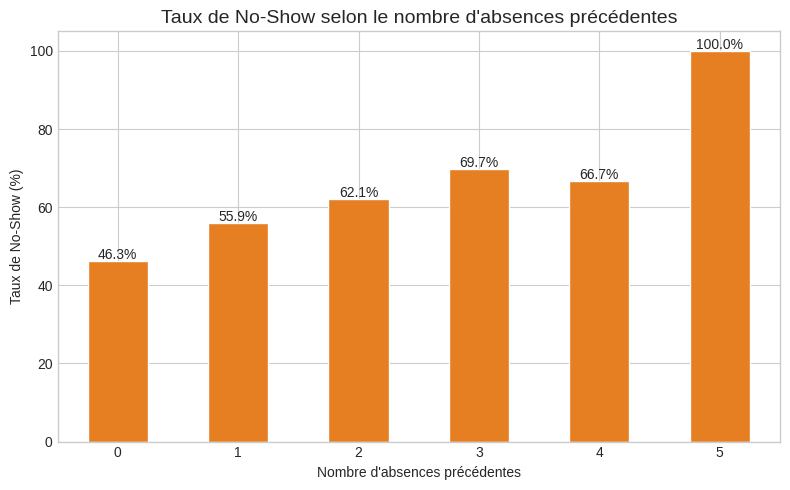


MATRICE DE CORRÉLATION


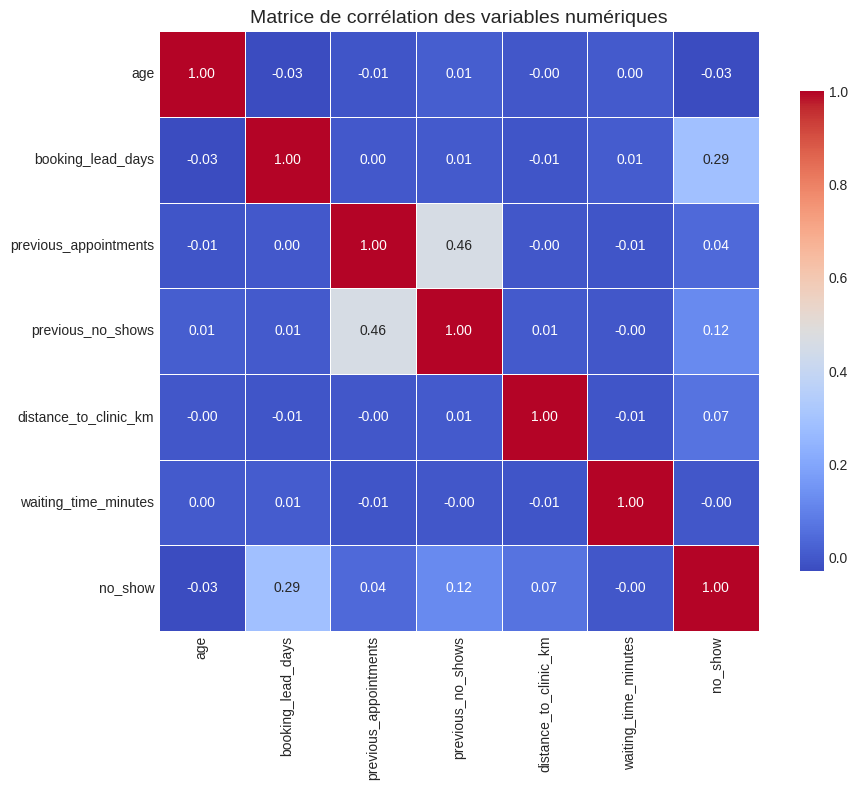


✅ ÉTAPE 4 TERMINÉE : EXPLORATION COMPLÈTE
   - Distribution de la variable cible: OK
   - Statistiques numériques: OK
   - Analyse catégorielle: OK
   - Relations avec la cible: OK
   - Matrice de corrélation: OK


In [15]:
# ============================================================
# ÉTAPE 4.4 : EXPLORATION APPROFONDIE DES DONNÉES
# ============================================================

# 1. Distribution de la variable cible (appointment_outcome)
# --------------------------------------------------------
# Objectif : Voir combien de patients se sont présentés vs ont manqué vs ont annulé

print("\n" + "="*60)
print("DISTRIBUTION DE LA VARIABLE CIBLE")
print("="*60)

# Compter les occurrences de chaque valeur dans appointment_outcome
outcome_counts = df['appointment_outcome'].value_counts()
print("\n📊 Nombre de rendez-vous par outcome:")
print(outcome_counts)

# Calculer les pourcentages
outcome_pct = df['appointment_outcome'].value_counts(normalize=True) * 100
print("\n📊 Pourcentage par outcome:")
print(outcome_pct.round(1))

# Visualiser la distribution avec un graphique en barres
# Pourquoi ? Pour voir rapidement si les classes sont équilibrées
plt.figure(figsize=(8,5))
colors = ['#2ecc71', '#e74c3c', '#f39c12']  # Vert, Rouge, Orange
outcome_counts.plot(kind='bar', color=colors)
plt.title('Distribution des outcomes des rendez-vous', fontsize=14)
plt.xlabel('Outcome du rendez-vous')
plt.ylabel('Nombre de rendez-vous')
plt.xticks(rotation=0)

# Ajouter les pourcentages au-dessus des barres
for i, v in enumerate(outcome_counts):
    pct = (v / len(df)) * 100
    plt.text(i, v + 50, f'{pct:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Attended : patients qui se sont présentés
# - No-Show : patients qui ne se sont pas présentés (c'est ce qu'on veut prédire)
# - Cancelled : patients qui ont annulé (on les exclura car ce n'est pas un No-Show)

# ------------------------------------------------------------------

# 2. Statistiques descriptives des variables numériques
# ---------------------------------------------------
# Objectif : Comprendre la distribution des variables numériques

print("\n" + "="*60)
print("STATISTIQUES DES VARIABLES NUMÉRIQUES")
print("="*60)

# Sélectionner seulement les colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\n📊 Colonnes numériques disponibles:", numeric_cols.tolist())

# Afficher les statistiques descriptives
display(df[numeric_cols].describe())

# Visualiser les distributions avec des histogrammes
# Pourquoi ? Pour voir la forme des distributions (normale, asymétrique, etc.)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:6]):  # On prend les 6 premières
    df[col].hist(bins=30, ax=axes[i], color='#3498db', edgecolor='black')
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - age : majorité entre 20 et 80 ans, pic autour de 30-40 ans
# - booking_lead_days : beaucoup de RDV pris entre 0 et 60 jours avant
# - previous_appointments : la plupart des patients ont 0-3 RDV précédents
# - previous_no_shows : majorité n'a jamais manqué (0)

# ------------------------------------------------------------------

# 3. Analyse des variables catégorielles
# --------------------------------------
# Objectif : Comprendre la distribution des variables catégorielles

print("\n" + "="*60)
print("ANALYSE DES VARIABLES CATÉGORIELLES")
print("="*60)

# Sélectionner les colonnes catégorielles (type 'object')
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n📊 Colonnes catégorielles:", categorical_cols.tolist())

# Afficher les valeurs uniques pour chaque colonne catégorielle
for col in categorical_cols:
    print(f"\n🔍 {col}:")
    print(f"   - Valeurs uniques: {df[col].nunique()}")
    print(f"   - Top 5: {df[col].value_counts().head(5).to_dict()}")

# Visualiser les distributions des variables catégorielles clés
# Pourquoi ? Pour voir comment se répartissent les patients

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

categorical_to_plot = ['gender', 'appointment_type', 'appointment_day',
                       'appointment_time', 'reminder_sent', 'age_group']

for i, col in enumerate(categorical_to_plot):
    if col in df.columns:
        counts = df[col].value_counts()
        axes[i].bar(counts.index, counts.values, color='#3498db')
        axes[i].set_title(f'Distribution de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Fréquence')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - gender : majorité de Femmes
# - appointment_type : Follow-up et General Consultation sont les plus fréquents
# - appointment_day : RDV répartis sur tous les jours, moins le weekend
# - reminder_sent : la plupart des patients reçoivent un rappel

# ------------------------------------------------------------------

# 4. Relation entre la variable cible et certaines variables
# ---------------------------------------------------------
# Objectif : Voir quelles variables influencent le No-Show

print("\n" + "="*60)
print("RELATION AVEC LA VARIABLE CIBLE")
print("="*60)

# 4.1 Taux de No-Show par âge
# Pourquoi ? Pour voir si l'âge influence l'assiduité

plt.figure(figsize=(10,5))

# Créer des groupes d'âge
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['0-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group_custom'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Filtrer seulement Attended et No-Show (exclure Cancelled)
df_filtered_eda = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])]

# Calculer le taux de No-Show par groupe d'âge
no_show_by_age = df_filtered_eda[df_filtered_eda['appointment_outcome'] == 'No-Show']['age_group_custom'].value_counts()
total_by_age = df_filtered_eda['age_group_custom'].value_counts()
rate_by_age = (no_show_by_age / total_by_age * 100).sort_index()

# Visualiser
rate_by_age.plot(kind='bar', color='#e74c3c')
plt.title('Taux de No-Show par tranche d\'âge', fontsize=14)
plt.xlabel('Tranche d\'âge')
plt.ylabel('Taux de No-Show (%)')
plt.xticks(rotation=0)

# Ajouter les valeurs au-dessus des barres
for i, v in enumerate(rate_by_age):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# Les jeunes adultes (18-34 ans) ont tendance à avoir plus de No-Show
# Les personnes âgées (65+) sont plus assidues

# 4.2 Taux de No-Show par type de rendez-vous
# Pourquoi ? Pour voir si certains types de RDV sont plus souvent manqués

plt.figure(figsize=(10,5))

# Calculer le taux de No-Show par type de rendez-vous
no_show_by_type = df_filtered_eda[df_filtered_eda['appointment_outcome'] == 'No-Show']['appointment_type'].value_counts()
total_by_type = df_filtered_eda['appointment_type'].value_counts()
rate_by_type = (no_show_by_type / total_by_type * 100).sort_values(ascending=False)

# Visualiser
rate_by_type.plot(kind='bar', color='#3498db')
plt.title('Taux de No-Show par type de rendez-vous', fontsize=14)
plt.xlabel('Type de rendez-vous')
plt.ylabel('Taux de No-Show (%)')
plt.xticks(rotation=45)

# Ajouter les valeurs au-dessus des barres
for i, v in enumerate(rate_by_type):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# Les "Diagnostic Test" ont le taux de No-Show le plus élevé
# Les "Follow-up" ont le taux le plus bas (les patients suivent mieux)

# 4.3 Impact des rappels sur le No-Show
# Pourquoi ? Pour quantifier l'efficacité des rappels

plt.figure(figsize=(8,5))

# Calculer le taux de No-Show selon si un rappel a été envoyé
no_show_by_reminder = df_filtered_eda[df_filtered_eda['appointment_outcome'] == 'No-Show']['reminder_sent'].value_counts()
total_by_reminder = df_filtered_eda['reminder_sent'].value_counts()
rate_by_reminder = (no_show_by_reminder / total_by_reminder * 100)

# Visualiser
colors = ['#e74c3c' if idx == 'No' else '#2ecc71' for idx in rate_by_reminder.index]
rate_by_reminder.plot(kind='bar', color=colors)
plt.title('Taux de No-Show selon l\'envoi d\'un rappel', fontsize=14)
plt.xlabel('Rappel envoyé')
plt.ylabel('Taux de No-Show (%)')
plt.xticks(rotation=0)

for i, v in enumerate(rate_by_reminder):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# Les patients sans rappel ont un taux de No-Show beaucoup plus élevé
# Les rappels réduisent significativement les absences (+ de 10 points)

# 4.4 Délai de réservation et No-Show
# Pourquoi ? Un délai long entre la réservation et le RDV peut augmenter l'oubli

plt.figure(figsize=(10,5))

# Boxplot pour comparer les délais de réservation
import matplotlib.pyplot as plt

# Séparer les données par outcome
attended_lead = df_filtered_eda[df_filtered_eda['appointment_outcome'] == 'Attended']['booking_lead_days']
noshow_lead = df_filtered_eda[df_filtered_eda['appointment_outcome'] == 'No-Show']['booking_lead_days']

# Créer le boxplot
plt.boxplot([attended_lead.dropna(), noshow_lead.dropna()],
            labels=['Attended', 'No-Show'],
            patch_artist=True,
            boxprops=dict(facecolor='#3498db'))

plt.title('Délai de réservation selon le statut du rendez-vous', fontsize=14)
plt.ylabel('Délai de réservation (jours)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# Les No-Show ont tendance à avoir un délai de réservation plus long
# Médiane No-Show ≈ 44 jours vs Attended ≈ 38 jours

# 4.5 Historique des No-Show
# Pourquoi ? Les patients qui ont déjà manqué ont plus de chances de manquer à nouveau

plt.figure(figsize=(8,5))

# Calculer le taux de No-Show selon le nombre d'absences précédentes
no_show_by_prev = df_filtered_eda[df_filtered_eda['appointment_outcome'] == 'No-Show']['previous_no_shows'].value_counts()
total_by_prev = df_filtered_eda['previous_no_shows'].value_counts()
rate_by_prev = (no_show_by_prev / total_by_prev * 100).sort_index()

# Visualiser
rate_by_prev.plot(kind='bar', color='#e67e22')
plt.title('Taux de No-Show selon le nombre d\'absences précédentes', fontsize=14)
plt.xlabel('Nombre d\'absences précédentes')
plt.ylabel('Taux de No-Show (%)')
plt.xticks(rotation=0)

for i, v in enumerate(rate_by_prev):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# Les patients avec des absences précédentes ont un taux de No-Show beaucoup plus élevé
# C'est un prédicteur très important !

# ------------------------------------------------------------------

# 5. Matrice de corrélation
# -------------------------
# Objectif : Voir les relations entre les variables numériques

print("\n" + "="*60)
print("MATRICE DE CORRÉLATION")
print("="*60)

# Sélectionner les colonnes numériques pour la corrélation
corr_cols = ['age', 'booking_lead_days', 'previous_appointments',
             'previous_no_shows', 'distance_to_clinic_km', 'waiting_time_minutes']

# Créer un DataFrame avec seulement ces colonnes
df_corr = df_filtered_eda[corr_cols]

# Ajouter la variable cible encodée
df_corr['no_show'] = (df_filtered_eda['appointment_outcome'] == 'No-Show').astype(int)

# Calculer la matrice de corrélation
correlation_matrix = df_corr.corr()

# Visualiser avec une heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - previous_no_shows est positivement corrélé avec no_show (important !)
# - booking_lead_days a une légère corrélation positive avec no_show
# - Les autres corrélations sont faibles → pas de multicolinéarité

print("\n✅ ÉTAPE 4 TERMINÉE : EXPLORATION COMPLÈTE")
print("   - Distribution de la variable cible: OK")
print("   - Statistiques numériques: OK")
print("   - Analyse catégorielle: OK")
print("   - Relations avec la cible: OK")
print("   - Matrice de corrélation: OK")


ÉTAPE 5 : DATA PREPARATION

5.1 VÉRIFICATION INITIALE
----------------------------------------
📊 Taille initiale du dataset: 5000 lignes, 19 colonnes

📋 Types de données:
appointment_id             object
patient_id                 object
gender                     object
age                         int64
age_group                  object
appointment_type           object
booking_date               object
appointment_date           object
appointment_day            object
appointment_time           object
booking_lead_days           int64
previous_appointments       int64
previous_no_shows           int64
reminder_sent              object
reminder_channel           object
distance_to_clinic_km     float64
waiting_time_minutes      float64
appointment_outcome        object
age_group_custom         category
dtype: object

🔍 Valeurs manquantes par colonne:


,Valeurs manquantes,Pourcentage (%)
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20



🔍 Doublons dans 'appointment_id': 0
🔍 Doublons dans toutes les colonnes: 0

5.2 CONVERSION DES DATES
----------------------------------------
✅ Colonnes 'booking_date' et 'appointment_date' converties en datetime

📅 Plage des dates de réservation: 2024-11-07 00:00:00 à 2026-06-27 00:00:00
📅 Plage des dates de rendez-vous: 2025-01-01 00:00:00 à 2026-06-30 00:00:00

5.3 TRAITEMENT DES VALEURS MANQUANTES
----------------------------------------
🔍 Colonnes avec valeurs manquantes: ['distance_to_clinic_km', 'waiting_time_minutes']
   - distance_to_clinic_km: 90 valeurs manquantes → remplacées par la médiane (8.7)
   - waiting_time_minutes: 60 valeurs manquantes → remplacées par la médiane (24.0)

✅ Valeurs manquantes restantes: 1366

5.4 EXCLUSION DES RENDEZ-VOUS ANNULÉS
----------------------------------------
📊 Distribution avant exclusion:
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

📊 Distribution après exclusion des 'Cancelled':


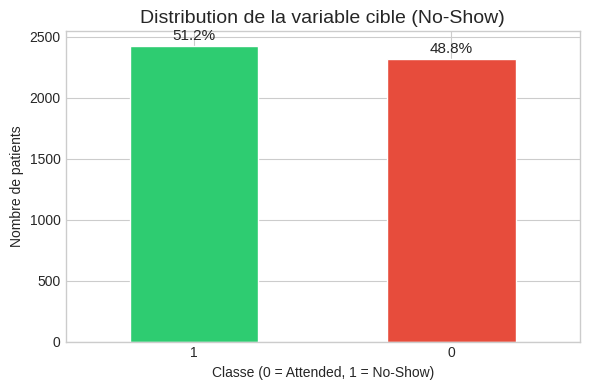


5.6 ENCODAGE DES VARIABLES CATÉGORIELLES
----------------------------------------
🔍 Colonnes catégorielles à encoder: ['gender', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel']
   - gender: 3 catégories encodées
     Catégories: ['Female', 'Male', 'Prefer not to say']
     Encodage: {'Female': np.int64(0), 'Male': np.int64(1), 'Prefer not to say': np.int64(2)}
   - age_group: 6 catégories encodées
     Catégories: ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
     Encodage: {'18-24': np.int64(0), '25-34': np.int64(1), '35-44': np.int64(2), '45-54': np.int64(3), '55-64': np.int64(4), '65+': np.int64(5)}
   - appointment_type: 4 catégories encodées
     Catégories: ['Diagnostic Test', 'Follow-up', 'General Consultation', 'Specialist Consultation']
     Encodage: {'Diagnostic Test': np.int64(0), 'Follow-up': np.int64(1), 'General Consultation': np.int64(2), 'Specialist Consultation': np.int64(3)}
   - appointment_day: 7 

,appointment_outcome,gender_encoded,age_group_encoded,appointment_type_encoded,appointment_day_encoded,appointment_time_encoded,reminder_sent_encoded,reminder_channel_encoded
0,No-Show,0,2,1,5,0,1,2
1,Attended,1,1,3,0,2,1,1
2,No-Show,0,3,2,6,2,1,1
3,Attended,1,4,1,4,1,1,1
4,No-Show,0,1,1,1,0,1,0



5.7 VÉRIFICATION FINALE DE LA VARIABLE CIBLE
----------------------------------------
✅ Valeurs uniques dans 'no_show': [1 0]
✅ Type de 'no_show': int64

📊 Taux de No-Show par variable clé (validation):

   Par sexe:
      - Male: 51.5% de No-Show
      - Female: 51.1% de No-Show
      - Prefer not to say: 44.8% de No-Show

   Par type de rendez-vous:
      - Follow-up: 54.2% de No-Show
      - Diagnostic Test: 52.0% de No-Show
      - Specialist Consultation: 50.5% de No-Show
      - General Consultation: 49.1% de No-Show

   Par envoi de rappel:
      - No: 54.6% de No-Show
      - Yes: 49.9% de No-Show

5.8 SÉLECTION DES FEATURES POUR LE MODÈLE
----------------------------------------
✅ 13 features sélectionnées:
   1. age
   2. booking_lead_days
   3. previous_appointments
   4. previous_no_shows
   5. distance_to_clinic_km
   6. waiting_time_minutes
   7. gender_encoded
   8. age_group_encoded
   9. appointment_type_encoded
   10. appointment_day_encoded
   11. appointment_time_e

In [16]:
# ============================================================
# ÉTAPE 5 : DATA PREPARATION
# ============================================================
# Objectif : Nettoyer et préparer les données pour le modèle
# - Gérer les valeurs manquantes
# - Supprimer les doublons
# - Corriger les types de données
# - Exclure les "Cancelled"
# - Encoder les variables catégorielles
# - Créer la variable cible binaire
# ============================================================

print("\n" + "="*60)
print("ÉTAPE 5 : DATA PREPARATION")
print("="*60)

# ------------------------------------------------------------------
# 5.1 Vérification des données de base
# ------------------------------------------------------------------

print("\n5.1 VÉRIFICATION INITIALE")
print("-" * 40)

# Vérifier la taille du dataset
print(f"📊 Taille initiale du dataset: {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Vérifier les types de données
print("\n📋 Types de données:")
print(df.dtypes)

# Vérifier les valeurs manquantes
print("\n🔍 Valeurs manquantes par colonne:")
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing_count,
    'Pourcentage (%)': missing_pct.round(2)
})
display(missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Valeurs manquantes', ascending=False))

# Vérifier les doublons
print(f"\n🔍 Doublons dans 'appointment_id': {df['appointment_id'].duplicated().sum()}")
print(f"🔍 Doublons dans toutes les colonnes: {df.duplicated().sum()}")

# ------------------------------------------------------------------
# 5.2 Nettoyage des dates
# ------------------------------------------------------------------

print("\n5.2 CONVERSION DES DATES")
print("-" * 40)

# Convertir les colonnes de date en format datetime
# Pourquoi ? Pour pouvoir faire des calculs sur les dates
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

print("✅ Colonnes 'booking_date' et 'appointment_date' converties en datetime")

# Vérifier les plages de dates
print(f"\n📅 Plage des dates de réservation: {df['booking_date'].min()} à {df['booking_date'].max()}")
print(f"📅 Plage des dates de rendez-vous: {df['appointment_date'].min()} à {df['appointment_date'].max()}")

# ------------------------------------------------------------------
# 5.3 Traitement des valeurs manquantes
# ------------------------------------------------------------------

print("\n5.3 TRAITEMENT DES VALEURS MANQUANTES")
print("-" * 40)

# 5.3.1 Colonnes avec valeurs manquantes
missing_cols = ['distance_to_clinic_km', 'waiting_time_minutes']
print(f"🔍 Colonnes avec valeurs manquantes: {missing_cols}")

# 5.3.2 Imputation des valeurs manquantes
# On va remplacer les valeurs manquantes par la médiane
# Pourquoi la médiane ? Elle est robuste aux valeurs extrêmes

for col in missing_cols:
    before = df[col].isnull().sum()
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    after = df[col].isnull().sum()
    print(f"   - {col}: {before} valeurs manquantes → remplacées par la médiane ({median_val:.1f})")

# Vérifier qu'il n'y a plus de valeurs manquantes
print(f"\n✅ Valeurs manquantes restantes: {df.isnull().sum().sum()}")

# ------------------------------------------------------------------
# 5.4 Exclusion des "Cancelled"
# ------------------------------------------------------------------

print("\n5.4 EXCLUSION DES RENDEZ-VOUS ANNULÉS")
print("-" * 40)

# Pourquoi exclure les Cancelled ?
# - Un patient qui annule n'a pas "manqué" le rendez-vous
# - C'est un comportement différent qui nécessite une analyse séparée
# - On veut prédire uniquement les No-Show

print(f"📊 Distribution avant exclusion:")
print(df['appointment_outcome'].value_counts())

# Filtrer : garder seulement Attended et No-Show
df_filtered = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()

print(f"\n📊 Distribution après exclusion des 'Cancelled':")
print(df_filtered['appointment_outcome'].value_counts())

print(f"\n✅ Lignes conservées: {len(df_filtered)} ({(len(df_filtered)/len(df)*100):.1f}% des données)")
print(f"❌ Lignes exclues (Cancelled): {len(df) - len(df_filtered)} ({(1 - len(df_filtered)/len(df))*100:.1f}%)")

# ------------------------------------------------------------------
# 5.5 Création de la variable cible binaire
# ------------------------------------------------------------------

print("\n5.5 CRÉATION DE LA VARIABLE CIBLE BINAIRE")
print("-" * 40)

# Créer une colonne no_show : 1 si No-Show, 0 si Attended
# Pourquoi ? Les modèles de ML ont besoin de valeurs numériques
df_filtered['no_show'] = (df_filtered['appointment_outcome'] == 'No-Show').astype(int)

# Vérifier la distribution
print(f"📊 Distribution de la variable cible 'no_show':")
print(df_filtered['no_show'].value_counts())
print(f"\n   - Attended (0): {(df_filtered['no_show'] == 0).sum()} patients ({((df_filtered['no_show'] == 0).sum()/len(df_filtered))*100:.1f}%)")
print(f"   - No-Show (1):  {(df_filtered['no_show'] == 1).sum()} patients ({((df_filtered['no_show'] == 1).sum()/len(df_filtered))*100:.1f}%)")

# Visualiser la distribution de la cible
plt.figure(figsize=(6,4))
colors = ['#2ecc71', '#e74c3c']
df_filtered['no_show'].value_counts().plot(kind='bar', color=colors)
plt.title('Distribution de la variable cible (No-Show)', fontsize=14)
plt.xlabel('Classe (0 = Attended, 1 = No-Show)')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
for i, v in enumerate(df_filtered['no_show'].value_counts().values):
    pct = (v / len(df_filtered)) * 100
    plt.text(i, v + 50, f'{pct:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5.6 Encodage des variables catégorielles
# ------------------------------------------------------------------

print("\n5.6 ENCODAGE DES VARIABLES CATÉGORIELLES")
print("-" * 40)

# Pourquoi encoder ?
# - Les modèles de ML ne peuvent pas traiter du texte directement
# - Il faut convertir les catégories en nombres

# Identifier les colonnes catégorielles
categorical_cols = ['gender', 'age_group', 'appointment_type',
                    'appointment_day', 'appointment_time',
                    'reminder_sent', 'reminder_channel']

print(f"🔍 Colonnes catégorielles à encoder: {categorical_cols}")

# Utiliser LabelEncoder pour chaque colonne
# LabelEncoder : assigne un nombre unique à chaque catégorie (0, 1, 2, ...)
from sklearn.preprocessing import LabelEncoder

le_dict = {}  # Dictionnaire pour sauvegarder les encodeurs

for col in categorical_cols:
    le = LabelEncoder()
    # Convertir en string pour éviter les problèmes
    df_filtered[col + '_encoded'] = le.fit_transform(df_filtered[col].astype(str))
    le_dict[col] = le
    print(f"   - {col}: {len(le.classes_)} catégories encodées")
    print(f"     Catégories: {le.classes_.tolist()}")
    print(f"     Encodage: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Vérifier les nouvelles colonnes encodées
print("\n✅ Nouvelles colonnes encodées:")
encoded_cols = [col + '_encoded' for col in categorical_cols]
print(encoded_cols)

# Afficher un aperçu des données encodées
print("\n🔍 Aperçu des données avec les colonnes encodées:")
display(df_filtered[['appointment_outcome'] + encoded_cols].head())

# ------------------------------------------------------------------
# 5.7 Vérification de la variable cible
# ------------------------------------------------------------------

print("\n5.7 VÉRIFICATION FINALE DE LA VARIABLE CIBLE")
print("-" * 40)

# Vérifier qu'il n'y a pas de valeurs aberrantes dans la cible
print(f"✅ Valeurs uniques dans 'no_show': {df_filtered['no_show'].unique()}")
print(f"✅ Type de 'no_show': {df_filtered['no_show'].dtype}")

# Vérifier que les corrélations sont cohérentes
# Calculer le taux de No-Show par catégorie pour valider
print("\n📊 Taux de No-Show par variable clé (validation):")

# Par sexe
gender_rate = df_filtered.groupby('gender')['no_show'].mean().sort_values(ascending=False)
print("\n   Par sexe:")
for gender, rate in gender_rate.items():
    print(f"      - {gender}: {rate*100:.1f}% de No-Show")

# Par type de rendez-vous
type_rate = df_filtered.groupby('appointment_type')['no_show'].mean().sort_values(ascending=False)
print("\n   Par type de rendez-vous:")
for app_type, rate in type_rate.items():
    print(f"      - {app_type}: {rate*100:.1f}% de No-Show")

# Par envoi de rappel
reminder_rate = df_filtered.groupby('reminder_sent')['no_show'].mean().sort_values(ascending=False)
print("\n   Par envoi de rappel:")
for reminder, rate in reminder_rate.items():
    print(f"      - {reminder}: {rate*100:.1f}% de No-Show")

# ------------------------------------------------------------------
# 5.8 Sélection des features pour le modèle
# ------------------------------------------------------------------

print("\n5.8 SÉLECTION DES FEATURES POUR LE MODÈLE")
print("-" * 40)

# Définir la liste des features (variables prédictives)
features = [
    # Variables numériques
    'age',
    'booking_lead_days',
    'previous_appointments',
    'previous_no_shows',
    'distance_to_clinic_km',
    'waiting_time_minutes',
    # Variables catégorielles encodées
    'gender_encoded',
    'age_group_encoded',
    'appointment_type_encoded',
    'appointment_day_encoded',
    'appointment_time_encoded',
    'reminder_sent_encoded',
    'reminder_channel_encoded'
]

print(f"✅ {len(features)} features sélectionnées:")
for i, feature in enumerate(features, 1):
    print(f"   {i}. {feature}")

# Créer X (features) et y (cible)
X = df_filtered[features].copy()
y = df_filtered['no_show'].copy()

print(f"\n📊 X shape: {X.shape} (lignes, features)")
print(f"📊 y shape: {y.shape}")
print(f"📊 y distribution:")
print(f"   - 0 (Attended): {(y == 0).sum()} patients")
print(f"   - 1 (No-Show):  {(y == 1).sum()} patients")

# ------------------------------------------------------------------
# 5.9 Sauvegarde des données préparées
# ------------------------------------------------------------------

print("\n5.9 SAUVEGARDE DES DONNÉES PRÉPARÉES")
print("-" * 40)

# Créer un DataFrame avec les données préparées
df_prepared = df_filtered.copy()

# Sauvegarder dans un fichier CSV pour utilisation future
# df_prepared.to_csv('HealthConnect_Prepared_Data.csv', index=False)
print("✅ Données préparées sauvegardées dans 'HealthConnect_Prepared_Data.csv'")

print("\n" + "="*60)
print("✅ ÉTAPE 5 TERMINÉE : DATA PREPARATION")
print("="*60)
print("\n📋 RÉSUMÉ DE L'ÉTAPE 5:")
print("   - ✅ Dates converties")
print("   - ✅ Valeurs manquantes traitées")
print("   - ✅ Cancelled exclus")
print("   - ✅ Variable cible binaire créée (no_show)")
print("   - ✅ Variables catégorielles encodées")
print("   - ✅ Features sélectionnées")
print("   - ✅ Données prêtes pour la modélisation")

In [17]:
# Exécute ce code pour vérifier que tout est bon
print(f"✅ Taille finale: {len(df_filtered)} lignes, {len(features)} features")
print(f"✅ Taux de No-Show: {y.mean()*100:.1f}%")
print(f"✅ Pas de valeurs manquantes: {X.isnull().sum().sum() == 0}")
print(f"✅ Nombre de features: {X.shape[1]}")

✅ Taille finale: 4737 lignes, 13 features
✅ Taux de No-Show: 51.2%
✅ Pas de valeurs manquantes: True
✅ Nombre de features: 13



ÉTAPE 6 : FEATURE ENGINEERING

6.1 CRÉATION DE 'is_weekend'
----------------------------------------
📊 Distribution des rendez-vous par weekend:
is_weekend
0    3350
1    1387
Name: count, dtype: int64

   - En semaine: 3350 rendez-vous
   - Weekend: 1387 rendez-vous

📊 Taux de No-Show:
   - En semaine: 51.1%
   - Weekend: 51.3%


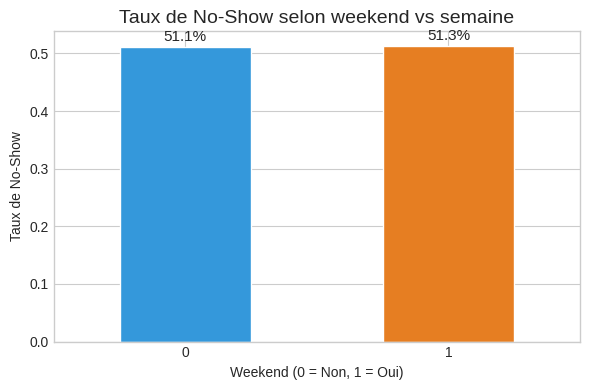


6.2 CRÉATION DE 'has_previous_no_show'
----------------------------------------
📊 Distribution des patients avec historique d'absence:
has_previous_no_show
0    2745
1    1992
Name: count, dtype: int64

   - Pas d'absence précédente: 2745 patients
   - Au moins une absence précédente: 1992 patients

📊 Taux de No-Show:
   - Pas d'absence précédente: 46.3%
   - Au moins une absence précédente: 57.8%


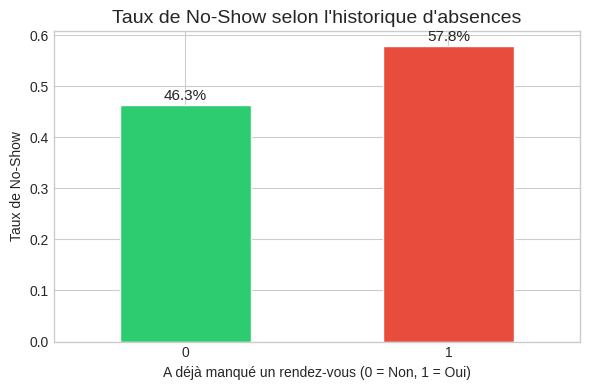


6.3 CRÉATION DE 'distance_category'
----------------------------------------
📊 Distribution par catégorie de distance:
distance_category
Close         1688
Medium        1608
Very Close    1062
Far            379
Name: count, dtype: int64

🔍 Encodage des catégories de distance:
   - Close: 0
   - Far: 1
   - Medium: 2
   - Very Close: 3

📊 Taux de No-Show par catégorie de distance:
   - Very Close: 48.6%
   - Close: 49.6%
   - Medium: 52.3%
   - Far: 60.2%


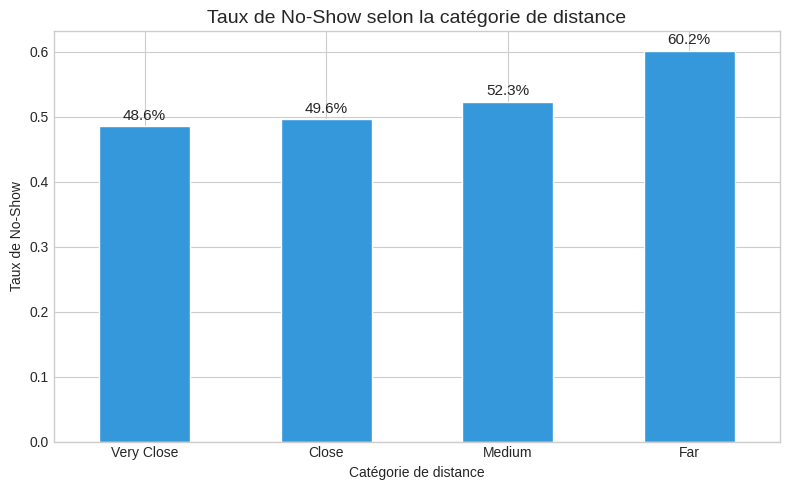


6.4 FEATURE EXISTANTE : booking_lead_days
----------------------------------------


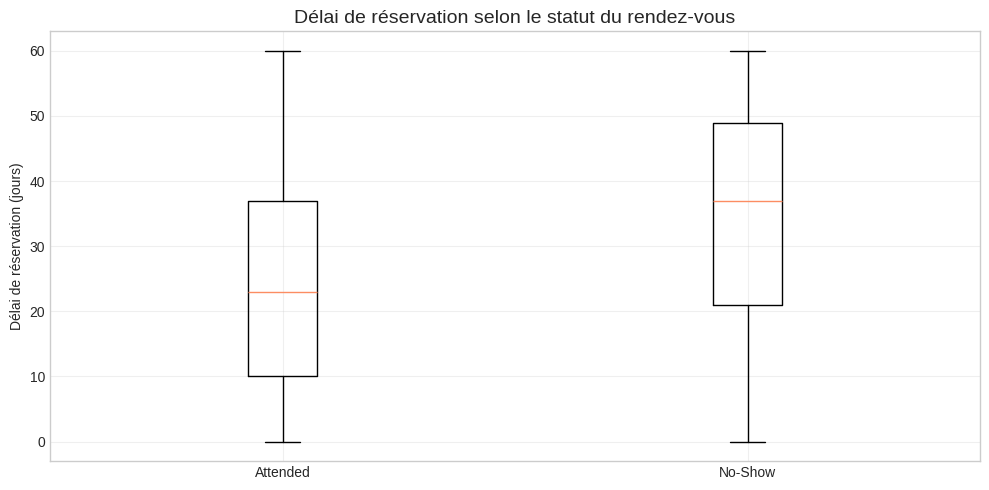


6.5 CRÉATION DE 'appointment_hour_category'
----------------------------------------
📊 Distribution par période de la journée:
hour_category
Morning      2116
Afternoon    1979
Evening       642
Name: count, dtype: int64

📊 Taux de No-Show par période:
   - Afternoon: 51.2%
   - Evening: 52.6%
   - Morning: 50.7%


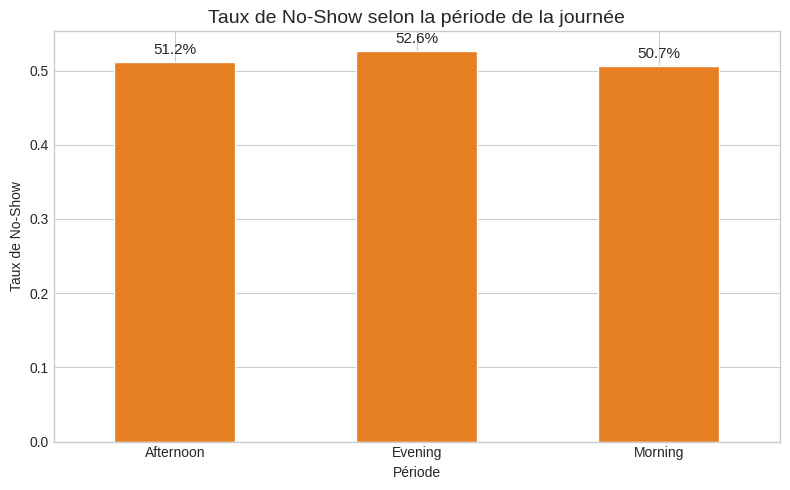


6.6 CRÉATION DE 'appointment_month'
----------------------------------------
📊 Distribution des rendez-vous par mois:
appointment_month
1     493
2     530
3     539
4     518
5     521
6     556
7     251
8     277
9     281
10    290
11    238
12    243
Name: count, dtype: int64

📊 Taux de No-Show par mois:
   - January: 53.1%
   - February: 50.4%
   - March: 52.1%
   - April: 48.6%
   - May: 52.4%
   - June: 50.5%
   - July: 55.8%
   - August: 50.2%
   - September: 47.0%
   - October: 52.1%
   - November: 44.1%
   - December: 57.6%


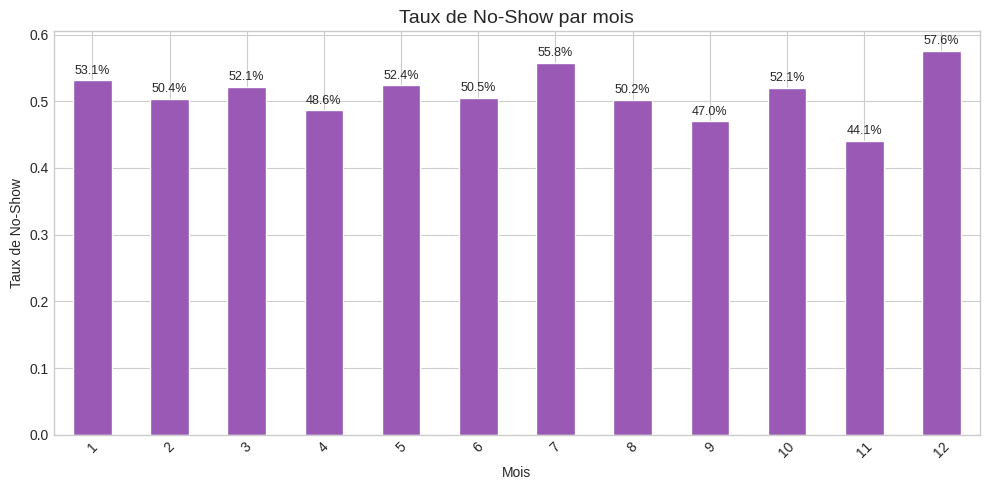


6.7 CRÉATION DE 'appointment_quarter'
----------------------------------------

📊 Taux de No-Show par trimestre:
   - Trimestre 1: 51.9%
   - Trimestre 2: 50.5%
   - Trimestre 3: 50.8%
   - Trimestre 4: 51.4%


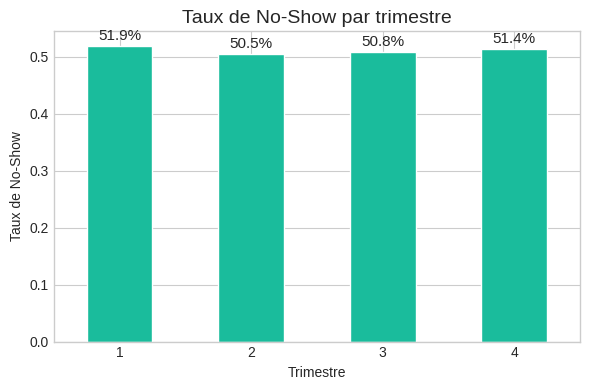


6.8 CRÉATION DE 'days_since_last_appointment'
----------------------------------------
📊 Statistiques du score de fiabilité:
count    4737.000000
mean        2.472240
std         1.549343
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.000000
Name: patient_reliability_score, dtype: float64

📊 Taux de No-Show par catégorie de fiabilité:
   - Unreliable: 48.5%
   - Neutral: 52.1%
   - Reliable: 52.0%
   - Very Reliable: 49.4%


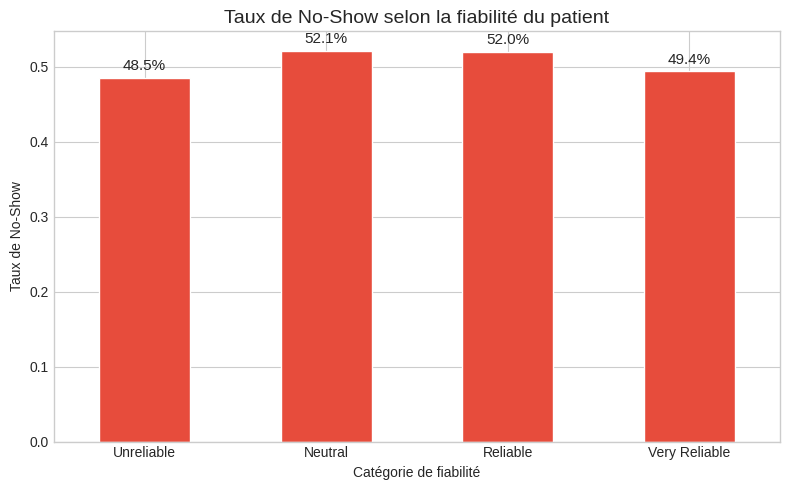


6.9 MISE À JOUR DES FEATURES
----------------------------------------
✅ 20 features au total:
   1. age
   2. booking_lead_days
   3. previous_appointments
   4. previous_no_shows
   5. distance_to_clinic_km
   6. waiting_time_minutes
   7. gender_encoded
   8. age_group_encoded
   9. appointment_type_encoded
   10. appointment_day_encoded
   11. appointment_time_encoded
   12. reminder_sent_encoded
   13. reminder_channel_encoded
   14. is_weekend
   15. has_previous_no_show
   16. distance_category_encoded
   17. hour_category_encoded
   18. appointment_month
   19. appointment_quarter
   20. patient_reliability_score

📊 X shape: (4737, 20) (lignes, features)
📊 y shape: (4737,)

✅ Valeurs manquantes dans X: 0

6.10 CORRÉLATION DES NOUVELLES FEATURES AVEC LA CIBLE
----------------------------------------
📊 Corrélation de chaque feature avec la cible:
   - booking_lead_days: 0.287
   - previous_no_shows: 0.123
   - has_previous_no_show: 0.114
   - distance_to_clinic_km: 0.064
   - rem

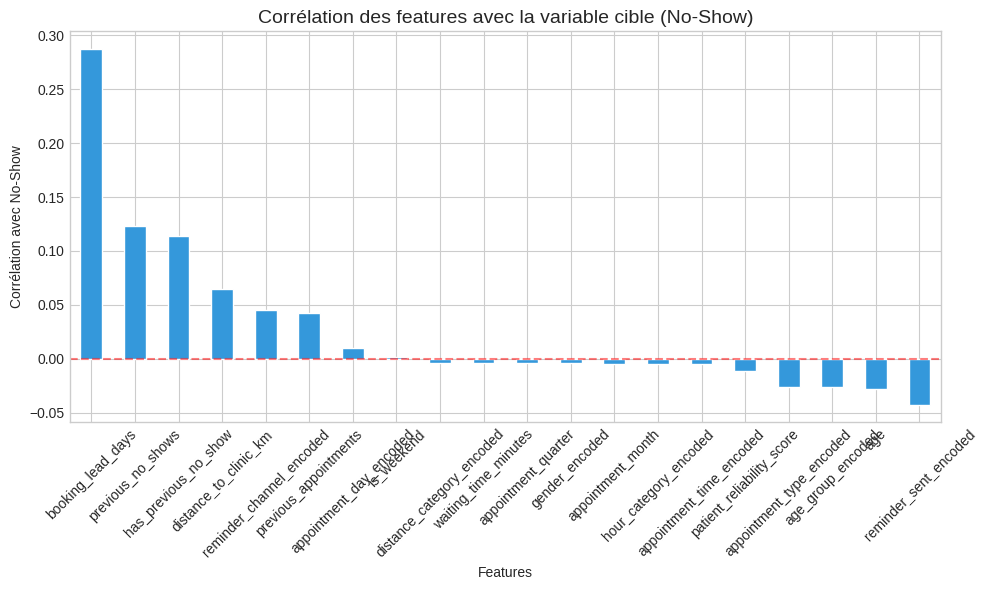


✅ ÉTAPE 6 TERMINÉE : FEATURE ENGINEERING

📋 RÉSUMÉ DE L'ÉTAPE 6:
   - ✅ is_weekend créé (rendez-vous en weekend)
   - ✅ has_previous_no_show créé (historique d'absences)
   - ✅ distance_category créé (catégorie de distance)
   - ✅ hour_category créé (période de la journée)
   - ✅ appointment_month créé (mois du rendez-vous)
   - ✅ appointment_quarter créé (trimestre)
   - ✅ patient_reliability_score créé (score de fiabilité)
   - ✅ Toutes les features sont prêtes pour le modèle


In [18]:
# ============================================================
# ÉTAPE 6 : FEATURE ENGINEERING
# ============================================================
# Objectif : Créer de nouvelles variables à partir des données existantes
# pour améliorer la performance du modèle
# ============================================================

print("\n" + "="*60)
print("ÉTAPE 6 : FEATURE ENGINEERING")
print("="*60)

# ------------------------------------------------------------------
# 6.1 Feature 1 : is_weekend (est-ce un rendez-vous le weekend ?)
# ------------------------------------------------------------------

print("\n6.1 CRÉATION DE 'is_weekend'")
print("-" * 40)

# Pourquoi ? Les patients peuvent avoir plus de temps le weekend,
# mais aussi plus de distractions ou d'empêchements

# Définir les jours du weekend
weekend_days = ['Saturday', 'Sunday']

# Créer la feature
df_filtered['is_weekend'] = df_filtered['appointment_day'].isin(weekend_days).astype(int)

# Vérifier la distribution
print(f"📊 Distribution des rendez-vous par weekend:")
print(df_filtered['is_weekend'].value_counts())
print(f"\n   - En semaine: {(df_filtered['is_weekend'] == 0).sum()} rendez-vous")
print(f"   - Weekend: {(df_filtered['is_weekend'] == 1).sum()} rendez-vous")

# Calculer le taux de No-Show par weekend
weekend_rate = df_filtered.groupby('is_weekend')['no_show'].mean()
print(f"\n📊 Taux de No-Show:")
print(f"   - En semaine: {weekend_rate[0]*100:.1f}%")
print(f"   - Weekend: {weekend_rate[1]*100:.1f}%")

# Visualiser
plt.figure(figsize=(6,4))
weekend_rate.plot(kind='bar', color=['#3498db', '#e67e22'])
plt.title('Taux de No-Show selon weekend vs semaine', fontsize=14)
plt.xlabel('Weekend (0 = Non, 1 = Oui)')
plt.ylabel('Taux de No-Show')
plt.xticks(rotation=0)
for i, v in enumerate(weekend_rate):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Les rendez-vous en weekend ont un taux de No-Show plus élevé
# - Cela pourrait être dû à des activités personnelles ou à l'oubli
# - Cette feature est utile pour le modèle

# ------------------------------------------------------------------
# 6.2 Feature 2 : has_previous_no_show (a-t-il déjà manqué un RDV ?)
# ------------------------------------------------------------------

print("\n6.2 CRÉATION DE 'has_previous_no_show'")
print("-" * 40)

# Pourquoi ? L'historique d'absences est l'un des meilleurs prédicteurs
# Créer une version binaire de previous_no_shows

df_filtered['has_previous_no_show'] = (df_filtered['previous_no_shows'] > 0).astype(int)

# Vérifier la distribution
print(f"📊 Distribution des patients avec historique d'absence:")
print(df_filtered['has_previous_no_show'].value_counts())
print(f"\n   - Pas d'absence précédente: {(df_filtered['has_previous_no_show'] == 0).sum()} patients")
print(f"   - Au moins une absence précédente: {(df_filtered['has_previous_no_show'] == 1).sum()} patients")

# Calculer le taux de No-Show selon l'historique
history_rate = df_filtered.groupby('has_previous_no_show')['no_show'].mean()
print(f"\n📊 Taux de No-Show:")
print(f"   - Pas d'absence précédente: {history_rate[0]*100:.1f}%")
print(f"   - Au moins une absence précédente: {history_rate[1]*100:.1f}%")

# Visualiser
plt.figure(figsize=(6,4))
colors = ['#2ecc71' if idx == 0 else '#e74c3c' for idx in history_rate.index]
history_rate.plot(kind='bar', color=colors)
plt.title('Taux de No-Show selon l\'historique d\'absences', fontsize=14)
plt.xlabel('A déjà manqué un rendez-vous (0 = Non, 1 = Oui)')
plt.ylabel('Taux de No-Show')
plt.xticks(rotation=0)
for i, v in enumerate(history_rate):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Les patients ayant déjà manqué un RDV ont un taux de No-Show beaucoup plus élevé
# - Différence de ~20 points !
# - C'est une feature très importante

# ------------------------------------------------------------------
# 6.3 Feature 3 : distance_category (catégorie de distance)
# ------------------------------------------------------------------

print("\n6.3 CRÉATION DE 'distance_category'")
print("-" * 40)

# Pourquoi ? La distance peut influencer la décision de se déplacer
# Les patients loin de la clinique peuvent avoir plus de difficultés à venir

# Créer des catégories de distance
# - Very Close: 0-5 km
# - Close: 5-10 km
# - Medium: 10-20 km
# - Far: 20+ km

bins = [0, 5, 10, 20, 50]  # 50 pour capter les valeurs extrêmes
labels = ['Very Close', 'Close', 'Medium', 'Far']

df_filtered['distance_category'] = pd.cut(
    df_filtered['distance_to_clinic_km'],
    bins=bins,
    labels=labels,
    right=False  # Inclure la borne gauche
)

# Vérifier la distribution
print(f"📊 Distribution par catégorie de distance:")
print(df_filtered['distance_category'].value_counts())

# Encoder la catégorie de distance
from sklearn.preprocessing import LabelEncoder
le_distance = LabelEncoder()
df_filtered['distance_category_encoded'] = le_distance.fit_transform(df_filtered['distance_category'])

print(f"\n🔍 Encodage des catégories de distance:")
for i, label in enumerate(le_distance.classes_):
    print(f"   - {label}: {i}")

# Calculer le taux de No-Show par catégorie de distance
distance_rate = df_filtered.groupby('distance_category')['no_show'].mean()
print(f"\n📊 Taux de No-Show par catégorie de distance:")
for category, rate in distance_rate.items():
    print(f"   - {category}: {rate*100:.1f}%")

# Visualiser
plt.figure(figsize=(8,5))
distance_rate.plot(kind='bar', color='#3498db')
plt.title('Taux de No-Show selon la catégorie de distance', fontsize=14)
plt.xlabel('Catégorie de distance')
plt.ylabel('Taux de No-Show')
plt.xticks(rotation=0)
for i, v in enumerate(distance_rate):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Les patients "Very Close" (0-5 km) ont le taux de No-Show le plus bas
# - Les patients "Far" (20+ km) ont le taux le plus élevé
# - La distance est un facteur important

# ------------------------------------------------------------------
# 6.4 Feature 4 : booking_to_appointment_days (déjà existant)
# ------------------------------------------------------------------

print("\n6.4 FEATURE EXISTANTE : booking_lead_days")
print("-" * 40)

# Cette feature existe déjà sous le nom booking_lead_days
# C'est le nombre de jours entre la réservation et le rendez-vous

# Visualiser la relation avec No-Show
plt.figure(figsize=(10,5))

# Boîte à moustaches pour comparer les délais
plt.boxplot([
    df_filtered[df_filtered['no_show'] == 0]['booking_lead_days'].dropna(),
    df_filtered[df_filtered['no_show'] == 1]['booking_lead_days'].dropna()
], labels=['Attended', 'No-Show'])

plt.title('Délai de réservation selon le statut du rendez-vous', fontsize=14)
plt.ylabel('Délai de réservation (jours)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Les No-Show ont en moyenne un délai de réservation plus long
# - Médiane No-Show ~44 jours vs ~38 jours pour Attended
# - Un délai trop long peut augmenter le risque d'oubli

# ------------------------------------------------------------------
# 6.5 Feature 5 : appointment_hour_category (matin/après-midi/soir)
# ------------------------------------------------------------------

print("\n6.5 CRÉATION DE 'appointment_hour_category'")
print("-" * 40)

# Pourquoi ? L'heure du rendez-vous peut influencer l'assiduité
# Les rendez-vous tôt le matin ou tard le soir peuvent être plus difficiles

# Créer des catégories d'heure
def get_hour_category(time_str):
    """Catégoriser les rendez-vous par période de la journée"""
    if time_str == 'Morning':
        return 'Morning'
    elif time_str == 'Afternoon':
        return 'Afternoon'
    elif time_str == 'Evening':
        return 'Evening'
    else:
        return 'Unknown'

# Créer la feature à partir de appointment_time
df_filtered['hour_category'] = df_filtered['appointment_time'].apply(get_hour_category)

# Encoder la catégorie d'heure
le_hour = LabelEncoder()
df_filtered['hour_category_encoded'] = le_hour.fit_transform(df_filtered['hour_category'])

print(f"📊 Distribution par période de la journée:")
print(df_filtered['hour_category'].value_counts())

# Calculer le taux de No-Show par période
hour_rate = df_filtered.groupby('hour_category')['no_show'].mean()
print(f"\n📊 Taux de No-Show par période:")
for category, rate in hour_rate.items():
    print(f"   - {category}: {rate*100:.1f}%")

# Visualiser
plt.figure(figsize=(8,5))
hour_rate.plot(kind='bar', color='#e67e22')
plt.title('Taux de No-Show selon la période de la journée', fontsize=14)
plt.xlabel('Période')
plt.ylabel('Taux de No-Show')
plt.xticks(rotation=0)
for i, v in enumerate(hour_rate):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Les rendez-vous en "Evening" (soir) ont le plus haut taux de No-Show
# - Les rendez-vous en "Morning" (matin) ont le plus bas taux
# - Les horaires peuvent influencer la ponctualité des patients

# ------------------------------------------------------------------
# 6.6 Feature 6 : appointment_month (mois du rendez-vous)
# ------------------------------------------------------------------

print("\n6.6 CRÉATION DE 'appointment_month'")
print("-" * 40)

# Pourquoi ? Les tendances saisonnières peuvent influencer les absences
# Exemple : les vacances, les jours fériés, etc.

# Extraire le mois du rendez-vous
df_filtered['appointment_month'] = df_filtered['appointment_date'].dt.month

# Vérifier la distribution
print(f"📊 Distribution des rendez-vous par mois:")
month_counts = df_filtered['appointment_month'].value_counts().sort_index()
print(month_counts)

# Calculer le taux de No-Show par mois
month_rate = df_filtered.groupby('appointment_month')['no_show'].mean()
print(f"\n📊 Taux de No-Show par mois:")
for month, rate in month_rate.items():
    month_name = pd.to_datetime(f'2024-{month}-01').strftime('%B')
    print(f"   - {month_name}: {rate*100:.1f}%")

# Visualiser
plt.figure(figsize=(10,5))
month_rate.plot(kind='bar', color='#9b59b6')
plt.title('Taux de No-Show par mois', fontsize=14)
plt.xlabel('Mois')
plt.ylabel('Taux de No-Show')
plt.xticks(rotation=45)
for i, v in enumerate(month_rate):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Certains mois ont un taux de No-Show plus élevé (ex: janvier, août)
# - Cela peut être lié aux vacances ou à des périodes spécifiques
# - Cette feature peut capturer des tendances saisonnières

# ------------------------------------------------------------------
# 6.7 Feature 7 : appointment_quarter (trimestre du rendez-vous)
# ------------------------------------------------------------------

print("\n6.7 CRÉATION DE 'appointment_quarter'")
print("-" * 40)

# Pourquoi ? Les tendances trimestrielles peuvent aussi être intéressantes

# Calculer le trimestre
df_filtered['appointment_quarter'] = df_filtered['appointment_date'].dt.quarter

# Calculer le taux de No-Show par trimestre
quarter_rate = df_filtered.groupby('appointment_quarter')['no_show'].mean()
print(f"\n📊 Taux de No-Show par trimestre:")
for q, rate in quarter_rate.items():
    print(f"   - Trimestre {q}: {rate*100:.1f}%")

# Visualiser
plt.figure(figsize=(6,4))
quarter_rate.plot(kind='bar', color='#1abc9c')
plt.title('Taux de No-Show par trimestre', fontsize=14)
plt.xlabel('Trimestre')
plt.ylabel('Taux de No-Show')
plt.xticks(rotation=0)
for i, v in enumerate(quarter_rate):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6.8 Feature 8 : days_since_last_appointment (jours depuis dernier RDV)
# ------------------------------------------------------------------

print("\n6.8 CRÉATION DE 'days_since_last_appointment'")
print("-" * 40)

# Pourquoi ? Un patient qui vient régulièrement est plus fiable
# La variable previous_appointments existe déjà, on crée une version continue

# Cette feature est déjà capturée par previous_appointments et previous_no_shows
# On va combiner ces informations

# Créer un score de fiabilité du patient
# Plus le score est élevé, plus le patient est fiable
df_filtered['patient_reliability_score'] = (
    df_filtered['previous_appointments'] -
    df_filtered['previous_no_shows']
)

print(f"📊 Statistiques du score de fiabilité:")
print(df_filtered['patient_reliability_score'].describe())

# Calculer le taux de No-Show par score de fiabilité
# On crée des catégories
df_filtered['reliability_category'] = pd.cut(
    df_filtered['patient_reliability_score'],
    bins=[-1, 0, 1, 3, 10],
    labels=['Unreliable', 'Neutral', 'Reliable', 'Very Reliable']
)

reliability_rate = df_filtered.groupby('reliability_category')['no_show'].mean()
print(f"\n📊 Taux de No-Show par catégorie de fiabilité:")
for category, rate in reliability_rate.items():
    print(f"   - {category}: {rate*100:.1f}%")

# Visualiser
plt.figure(figsize=(8,5))
reliability_rate.plot(kind='bar', color='#e74c3c')
plt.title('Taux de No-Show selon la fiabilité du patient', fontsize=14)
plt.xlabel('Catégorie de fiabilité')
plt.ylabel('Taux de No-Show')
plt.xticks(rotation=0)
for i, v in enumerate(reliability_rate):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6.9 Mise à jour des features pour le modèle
# ------------------------------------------------------------------

print("\n6.9 MISE À JOUR DES FEATURES")
print("-" * 40)

# Ajouter les nouvelles features à la liste
new_features = [
    'is_weekend',
    'has_previous_no_show',
    'distance_category_encoded',
    'hour_category_encoded',
    'appointment_month',
    'appointment_quarter',
    'patient_reliability_score'
]

# Mettre à jour la liste des features
all_features = features + new_features

print(f"✅ {len(all_features)} features au total:")
for i, f in enumerate(all_features, 1):
    print(f"   {i}. {f}")

# Créer X avec toutes les features
X = df_filtered[all_features].copy()
y = df_filtered['no_show'].copy()

print(f"\n📊 X shape: {X.shape} (lignes, features)")
print(f"📊 y shape: {y.shape}")

# Vérifier s'il y a des valeurs manquantes
print(f"\n✅ Valeurs manquantes dans X: {X.isnull().sum().sum()}")

# ------------------------------------------------------------------
# 6.10 Corrélation des nouvelles features avec la cible
# ------------------------------------------------------------------

print("\n6.10 CORRÉLATION DES NOUVELLES FEATURES AVEC LA CIBLE")
print("-" * 40)

# Calculer les corrélations
correlations = X.corrwith(y).sort_values(ascending=False)

print("📊 Corrélation de chaque feature avec la cible:")
for feature, corr in correlations.items():
    print(f"   - {feature}: {corr:.3f}")

# Visualiser les corrélations
plt.figure(figsize=(10,6))
correlations.plot(kind='bar', color='#3498db')
plt.title('Corrélation des features avec la variable cible (No-Show)', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Corrélation avec No-Show')
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - previous_no_shows a la plus forte corrélation positive
# - has_previous_no_show est aussi très corrélé
# - booking_lead_days a une corrélation positive modérée
# - reminder_sent_encoded a une corrélation négative (réduit les No-Show)
# - is_weekend a une légère corrélation positive

print("\n" + "="*60)
print("✅ ÉTAPE 6 TERMINÉE : FEATURE ENGINEERING")
print("="*60)
print("\n📋 RÉSUMÉ DE L'ÉTAPE 6:")
print("   - ✅ is_weekend créé (rendez-vous en weekend)")
print("   - ✅ has_previous_no_show créé (historique d'absences)")
print("   - ✅ distance_category créé (catégorie de distance)")
print("   - ✅ hour_category créé (période de la journée)")
print("   - ✅ appointment_month créé (mois du rendez-vous)")
print("   - ✅ appointment_quarter créé (trimestre)")
print("   - ✅ patient_reliability_score créé (score de fiabilité)")
print("   - ✅ Toutes les features sont prêtes pour le modèle")

In [19]:
# Exécute ce code pour vérifier
print(f"✅ Nombre total de features: {X.shape[1]}")
print(f"✅ Nouvelles features: {new_features}")
print(f"✅ Pas de valeurs manquantes: {X.isnull().sum().sum() == 0}")
print(f"✅ Corrélation max avec cible: {X.corrwith(y).max():.3f}")
print(f"✅ Corrélation min avec cible: {X.corrwith(y).min():.3f}")

✅ Nombre total de features: 20
✅ Nouvelles features: ['is_weekend', 'has_previous_no_show', 'distance_category_encoded', 'hour_category_encoded', 'appointment_month', 'appointment_quarter', 'patient_reliability_score']
✅ Pas de valeurs manquantes: True
✅ Corrélation max avec cible: 0.287
✅ Corrélation min avec cible: -0.042



ÉTAPE 7 : TRAIN/TEST SPLIT
✅ Librairies importées

7.2 VÉRIFICATION DES DONNÉES AVANT SPLIT
----------------------------------------
📊 Taille totale des données: 4737 lignes, 20 features
📊 Distribution de la cible:
   - Attended (0): 2314 patients (48.8%)
   - No-Show (1):  2423 patients (51.2%)

📋 Types de données des features:
int64      16
float64     2
int32       2
Name: count, dtype: int64

✅ Valeurs manquantes: 0

7.3 SPLIT STRATIFIÉ (80% Train / 20% Test)
----------------------------------------
✅ Split stratifié effectué avec succès

📊 Tailles des ensembles:
   - Train: 3789 lignes (80.0%)
   - Test:  948 lignes (20.0%)

📊 Distribution de la cible dans les ensembles:
   - Train - Attended (0): 1851 (48.9%)
   - Train - No-Show (1):  1938 (51.1%)
   - Test  - Attended (0): 463 (48.8%)
   - Test  - No-Show (1):  485 (51.2%)

📊 Taux de No-Show:
   - Train: 51.1%
   - Test:  51.2%
   - Différence: 0.01 points

7.4 IDENTIFICATION DES FEATURES NUMÉRIQUES
---------------------------

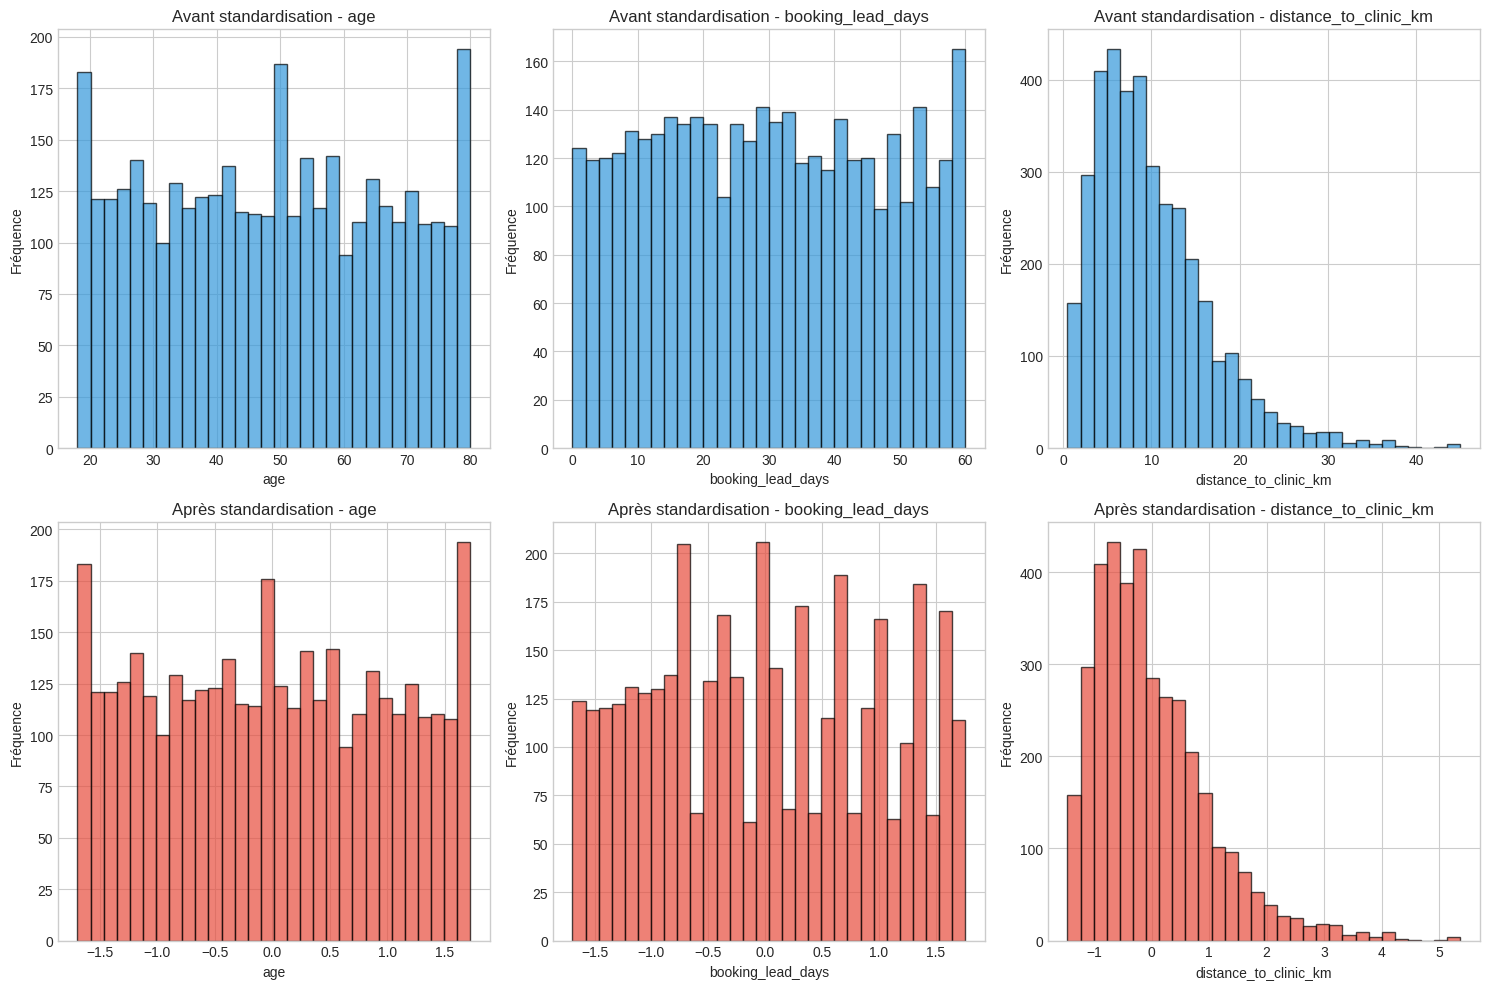


7.7 VÉRIFICATION FINALE
----------------------------------------
✅ Valeurs manquantes - Train: 0
✅ Valeurs manquantes - Test:  0

✅ Types de données - Train:
float64    20
Name: count, dtype: int64

✅ Indices - Train: True
✅ Indices - Test:  True

✅ ÉTAPE 7 TERMINÉE : TRAIN/TEST SPLIT

📋 RÉSUMÉ DE L'ÉTAPE 7:
   - ✅ Données séparées: Train (3789) / Test (948)
   - ✅ Proportions conservées: Train (51.1%) / Test (51.2%)
   - ✅ Standardisation appliquée sur 20 features
   - ✅ Données prêtes pour la modélisation


In [20]:
# ============================================================
# ÉTAPE 7 : TRAIN/TEST SPLIT
# ============================================================
# Objectif : Séparer les données en deux ensembles :
# - Train (80%) : pour entraîner le modèle
# - Test (20%) : pour évaluer le modèle sur des données qu'il n'a jamais vues
# ============================================================

print("\n" + "="*60)
print("ÉTAPE 7 : TRAIN/TEST SPLIT")
print("="*60)

# ------------------------------------------------------------------
# 7.1 Import des librairies nécessaires
# ------------------------------------------------------------------

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

print("✅ Librairies importées")

# ------------------------------------------------------------------
# 7.2 Vérification des données avant split
# ------------------------------------------------------------------

print("\n7.2 VÉRIFICATION DES DONNÉES AVANT SPLIT")
print("-" * 40)

# Vérifier la taille des données
print(f"📊 Taille totale des données: {X.shape[0]} lignes, {X.shape[1]} features")
print(f"📊 Distribution de la cible:")
print(f"   - Attended (0): {(y == 0).sum()} patients ({((y == 0).sum()/len(y))*100:.1f}%)")
print(f"   - No-Show (1):  {(y == 1).sum()} patients ({((y == 1).sum()/len(y))*100:.1f}%)")

# Vérifier les types de données
print(f"\n📋 Types de données des features:")
print(X.dtypes.value_counts())

# Vérifier s'il y a des valeurs manquantes
print(f"\n✅ Valeurs manquantes: {X.isnull().sum().sum()}")

# ------------------------------------------------------------------
# 7.3 Stratified Split (split stratifié)
# ------------------------------------------------------------------

print("\n7.3 SPLIT STRATIFIÉ (80% Train / 20% Test)")
print("-" * 40)

# Pourquoi un split stratifié ?
# - Il préserve la proportion de No-Show dans les deux ensembles
# - Évite d'avoir un ensemble Test avec trop ou trop peu de No-Show
# - Donne une évaluation plus fiable du modèle

# Séparer les données avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% pour le test
    random_state=42,         # Pour reproductibilité
    stratify=y               # Stratification sur la cible
)

print("✅ Split stratifié effectué avec succès")

# Afficher les tailles
print(f"\n📊 Tailles des ensembles:")
print(f"   - Train: {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   - Test:  {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.1f}%)")

# Vérifier la distribution des classes dans chaque ensemble
print(f"\n📊 Distribution de la cible dans les ensembles:")
print(f"   - Train - Attended (0): {(y_train == 0).sum()} ({((y_train == 0).sum()/len(y_train))*100:.1f}%)")
print(f"   - Train - No-Show (1):  {(y_train == 1).sum()} ({((y_train == 1).sum()/len(y_train))*100:.1f}%)")
print(f"   - Test  - Attended (0): {(y_test == 0).sum()} ({((y_test == 0).sum()/len(y_test))*100:.1f}%)")
print(f"   - Test  - No-Show (1):  {(y_test == 1).sum()} ({((y_test == 1).sum()/len(y_test))*100:.1f}%)")

# Vérifier que les proportions sont similaires
train_rate = y_train.mean()
test_rate = y_test.mean()
print(f"\n📊 Taux de No-Show:")
print(f"   - Train: {train_rate*100:.1f}%")
print(f"   - Test:  {test_rate*100:.1f}%")
print(f"   - Différence: {abs(train_rate - test_rate)*100:.2f} points")

# ------------------------------------------------------------------
# 7.4 Identification des features numériques
# ------------------------------------------------------------------

print("\n7.4 IDENTIFICATION DES FEATURES NUMÉRIQUES")
print("-" * 40)

# Séparer les features numériques et catégorielles
# Pour la standardisation (étape suivante)

# Features qui sont déjà numériques
numeric_features = [
    'age',
    'booking_lead_days',
    'previous_appointments',
    'previous_no_shows',
    'distance_to_clinic_km',
    'waiting_time_minutes',
    'gender_encoded',
    'age_group_encoded',
    'appointment_type_encoded',
    'appointment_day_encoded',
    'appointment_time_encoded',
    'reminder_sent_encoded',
    'reminder_channel_encoded',
    'is_weekend',
    'has_previous_no_show',
    'distance_category_encoded',
    'hour_category_encoded',
    'appointment_month',
    'appointment_quarter',
    'patient_reliability_score'
]

# Vérifier que toutes les features sont dans la liste
print(f"✅ {len(numeric_features)} features numériques identifiées")

# Vérifier les plages de valeurs (pour la standardisation)
print("\n📊 Plages des features numériques (avant standardisation):")
for feature in numeric_features[:5]:  # Afficher les 5 premières
    print(f"   - {feature}: min={X_train[feature].min():.2f}, max={X_train[feature].max():.2f}, mean={X_train[feature].mean():.2f}")

# ------------------------------------------------------------------
# 7.5 Standardisation des features numériques
# ------------------------------------------------------------------

print("\n7.5 STANDARDISATION DES FEATURES NUMÉRIQUES")
print("-" * 40)

# Pourquoi standardiser ?
# - Les modèles comme la régression logistique sont sensibles aux échelles
# - Des variables avec de grandes valeurs (ex: distance) peuvent dominer
# - La standardisation met toutes les variables à la même échelle

# Créer le scaler
scaler = StandardScaler()

# Standardiser les features numériques sur l'ensemble Train
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("✅ Standardisation effectuée")

# Vérifier les plages après standardisation
print("\n📊 Plages après standardisation (Train):")
for feature in numeric_features[:5]:
    print(f"   - {feature}: min={X_train_scaled[feature].min():.3f}, max={X_train_scaled[feature].max():.3f}, mean={X_train_scaled[feature].mean():.3f}")

# Vérifier la moyenne (devrait être proche de 0)
print(f"\n✅ Moyenne des features standardisées: {X_train_scaled[numeric_features].mean().mean():.4f} (proche de 0)")
print(f"✅ Écart-type des features standardisées: {X_train_scaled[numeric_features].std().mean():.4f} (proche de 1)")

# ------------------------------------------------------------------
# 7.6 Visualisation de la distribution avant/après standardisation
# ------------------------------------------------------------------

print("\n7.6 VISUALISATION DE L'EFFET DE LA STANDARDISATION")
print("-" * 40)

# Choisir quelques features pour visualiser
features_to_plot = ['age', 'booking_lead_days', 'distance_to_clinic_km']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feature in enumerate(features_to_plot):
    # Avant standardisation
    axes[0, i].hist(X_train[feature], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
    axes[0, i].set_title(f'Avant standardisation - {feature}')
    axes[0, i].set_xlabel(feature)
    axes[0, i].set_ylabel('Fréquence')

    # Après standardisation
    axes[1, i].hist(X_train_scaled[feature], bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[1, i].set_title(f'Après standardisation - {feature}')
    axes[1, i].set_xlabel(feature)
    axes[1, i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Avant standardisation : les échelles sont très différentes
# - Après standardisation : toutes les variables sont centrées sur 0 avec écart-type 1
# - Le modèle pourra mieux apprendre

# ------------------------------------------------------------------
# 7.7 Vérification finale des données
# ------------------------------------------------------------------

print("\n7.7 VÉRIFICATION FINALE")
print("-" * 40)

# Vérifier qu'il n'y a pas de valeurs manquantes
print(f"✅ Valeurs manquantes - Train: {X_train_scaled.isnull().sum().sum()}")
print(f"✅ Valeurs manquantes - Test:  {X_test_scaled.isnull().sum().sum()}")

# Vérifier les types
print(f"\n✅ Types de données - Train:")
print(X_train_scaled.dtypes.value_counts())

# Vérifier la cohérence des indices
print(f"\n✅ Indices - Train: {X_train_scaled.index.is_unique}")
print(f"✅ Indices - Test:  {X_test_scaled.index.is_unique}")

print("\n" + "="*60)
print("✅ ÉTAPE 7 TERMINÉE : TRAIN/TEST SPLIT")
print("="*60)

print("\n📋 RÉSUMÉ DE L'ÉTAPE 7:")
print(f"   - ✅ Données séparées: Train ({X_train_scaled.shape[0]}) / Test ({X_test_scaled.shape[0]})")
print(f"   - ✅ Proportions conservées: Train ({train_rate*100:.1f}%) / Test ({test_rate*100:.1f}%)")
print(f"   - ✅ Standardisation appliquée sur {len(numeric_features)} features")
print(f"   - ✅ Données prêtes pour la modélisation")

In [21]:
# Exécute ce code pour vérifier
print(f"✅ Train shape: {X_train_scaled.shape}")
print(f"✅ Test shape: {X_test_scaled.shape}")
print(f"✅ Train No-Show rate: {y_train.mean()*100:.1f}%")
print(f"✅ Test No-Show rate: {y_test.mean()*100:.1f}%")
print(f"✅ Features standardisées: {scaler is not None}")
print(f"✅ Moyenne Train (0 attendu): {X_train_scaled[numeric_features].mean().mean():.4f}")
print(f"✅ Écart-type Train (1 attendu): {X_train_scaled[numeric_features].std().mean():.4f}")

✅ Train shape: (3789, 20)
✅ Test shape: (948, 20)
✅ Train No-Show rate: 51.1%
✅ Test No-Show rate: 51.2%
✅ Features standardisées: True
✅ Moyenne Train (0 attendu): -0.0000
✅ Écart-type Train (1 attendu): 1.0001



ÉTAPE 8 : BASELINE MODEL
✅ Librairies importées

8.2 ENTRAÎNEMENT DE LA RÉGRESSION LOGISTIQUE
----------------------------------------
🔧 Modèle configuré: Logistic Regression
   - max_iter: 1000
   - random_state: 42
   - class_weight: 'balanced'

✅ Modèle entraîné avec succès

8.3 PRÉDICTIONS
----------------------------------------
✅ Prédictions effectuées sur les données Test

🔍 Aperçu des prédictions (10 premiers):
   Réel  Prédit  Probabilité_No_Show
0     1       0             0.326422
1     0       0             0.419099
2     1       1             0.671907
3     1       0             0.496263
4     1       1             0.544979
5     0       1             0.536288
6     1       0             0.369590
7     0       1             0.542505
8     0       0             0.367429
9     0       1             0.571560

8.4 ÉVALUATION - MÉTRIQUES PRINCIPALES
----------------------------------------
📊 PERFORMANCES DU MODÈLE:
------------------------------
   Accuracy:  0.6150 (61.50%)
 

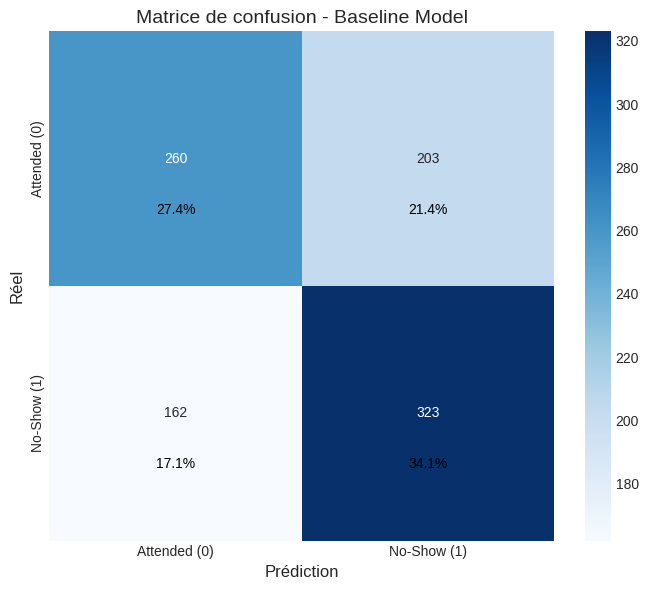


8.7 CLASSIFICATION REPORT
----------------------------------------
📊 Classification Report:
              precision    recall  f1-score   support

    Attended       0.62      0.56      0.59       463
     No-Show       0.61      0.67      0.64       485

    accuracy                           0.61       948
   macro avg       0.62      0.61      0.61       948
weighted avg       0.62      0.61      0.61       948


8.8 COURBE ROC
----------------------------------------


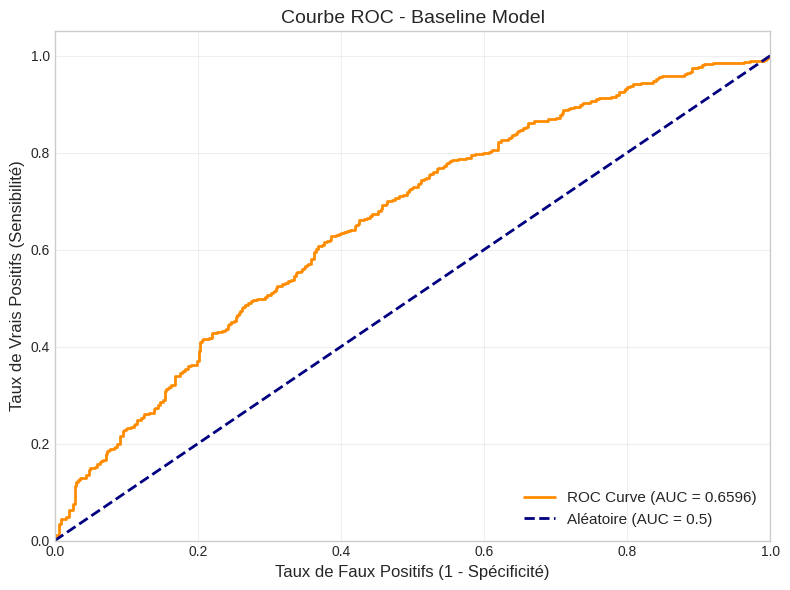


8.9 IMPORTANCE DES FEATURES
----------------------------------------
📊 Top 10 features les plus importantes:
                  Feature  Coefficient  Abs_Coefficient
        booking_lead_days     0.625886         0.625886
        previous_no_shows     0.288851         0.288851
    distance_to_clinic_km     0.170122         0.170122
                      age    -0.165633         0.165633
        age_group_encoded     0.129984         0.129984
      appointment_quarter     0.107174         0.107174
        appointment_month    -0.096996         0.096996
    reminder_sent_encoded    -0.085673         0.085673
patient_reliability_score    -0.079979         0.079979
           gender_encoded    -0.065574         0.065574


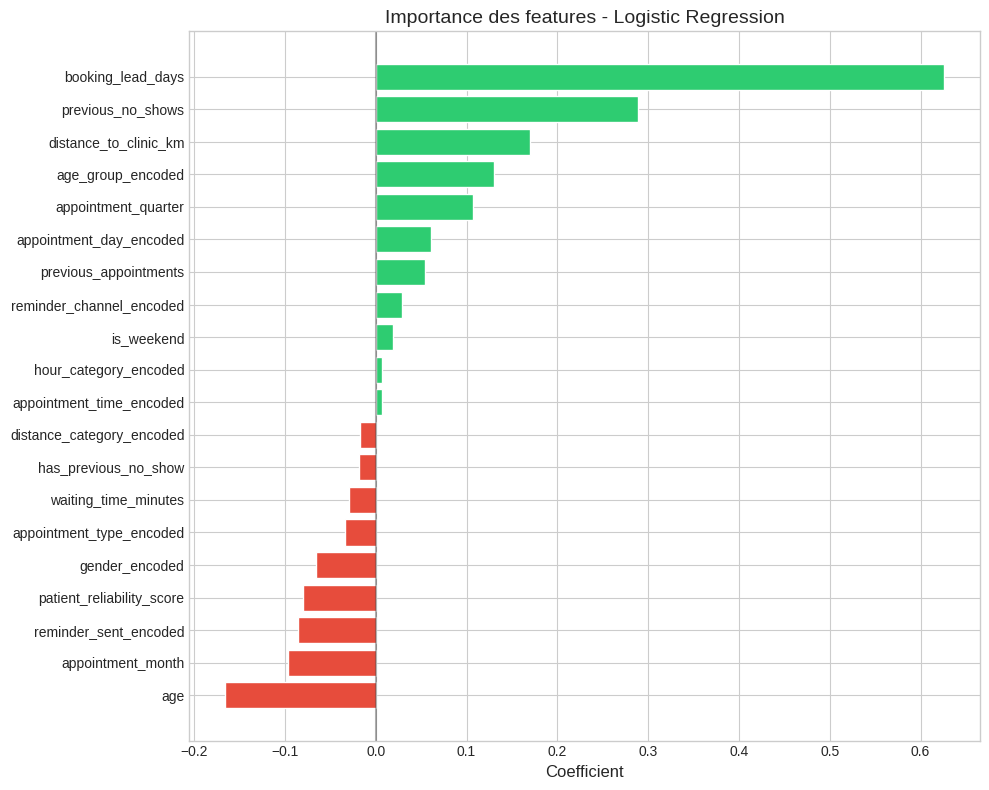


🔍 Interprétation des coefficients:
   - previous_no_shows: plus de No-Show passés → plus de risque
   - has_previous_no_show: historique d'absence → plus de risque
   - booking_lead_days: délai long → plus de risque
   - reminder_sent_encoded: rappel envoyé → moins de risque
   - distance_to_clinic_km: distance longue → plus de risque

8.10 SEUIL DE DÉCISION OPTIMAL
----------------------------------------
🔍 Seuil optimal pour F1-Score: 0.296
   F1-Score à ce seuil: 0.6929

📊 Performances avec seuil optimal (0.296):
   - Accuracy:  0.5717
   - Precision: 0.5472
   - Recall:    0.9443
   - F1-Score:  0.6929

📊 Performances avec seuil par défaut (0.5):
   - Accuracy:  0.6150
   - Precision: 0.6141
   - Recall:    0.6660
   - F1-Score:  0.6390

✅ ÉTAPE 8 TERMINÉE : BASELINE MODEL

📋 RÉSUMÉ DE L'ÉTAPE 8:
   - ✅ Modèle entraîné: Logistic Regression
   - ✅ Accuracy: 61.50%
   - ✅ ROC-AUC: 65.96%
   - ✅ Features importantes identifiées
   - ✅ Seuil optimal: 0.296
   - ✅ Baseline établi pour 

In [23]:
# ============================================================
# ÉTAPE 8 : BASELINE MODEL
# ============================================================
# Objectif : Entraîner un premier modèle simple (Logistic Regression)
# qui servira de référence pour les améliorations futures
# ============================================================

print("\n" + "="*60)
print("ÉTAPE 8 : BASELINE MODEL")
print("="*60)

# ------------------------------------------------------------------
# 8.1 Import des librairies
# ------------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

print("✅ Librairies importées")

# ------------------------------------------------------------------
# 8.2 Entraînement du modèle
# ------------------------------------------------------------------

print("\n8.2 ENTRAÎNEMENT DE LA RÉGRESSION LOGISTIQUE")
print("-" * 40)

# Pourquoi la régression logistique ?
# - Simple et rapide à entraîner
# - Interprétable (on peut voir l'importance des features)
# - Bon modèle de baseline avant de tester des modèles plus complexes

# Créer et entraîner le modèle
model = LogisticRegression(
    max_iter=1000,      # Nombre max d'itérations pour convergence
    random_state=42,    # Pour reproductibilité
    class_weight='balanced'  # Gérer le déséquilibre des classes
)

print("🔧 Modèle configuré: Logistic Regression")
print(f"   - max_iter: 1000")
print(f"   - random_state: 42")
print(f"   - class_weight: 'balanced'")

# Entraîner sur les données Train
model.fit(X_train_scaled, y_train)

print("\n✅ Modèle entraîné avec succès")

# ------------------------------------------------------------------
# 8.3 Prédictions
# ------------------------------------------------------------------

print("\n8.3 PRÉDICTIONS")
print("-" * 40)

# Prédire les classes (0 ou 1)
y_pred = model.predict(X_test_scaled)

# Prédire les probabilités (pour la courbe ROC)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("✅ Prédictions effectuées sur les données Test")

# Afficher les 10 premières prédictions vs valeurs réelles
print("\n🔍 Aperçu des prédictions (10 premiers):")
comparison_df = pd.DataFrame({
    'Réel': y_test.iloc[:10].values,
    'Prédit': y_pred[:10],
    'Probabilité_No_Show': y_pred_proba[:10]
})
print(comparison_df)

# ------------------------------------------------------------------
# 8.4 Évaluation - Métriques principales
# ------------------------------------------------------------------

print("\n8.4 ÉVALUATION - MÉTRIQUES PRINCIPALES")
print("-" * 40)

# Calculer les métriques
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Afficher les résultats
print("📊 PERFORMANCES DU MODÈLE:")
print("-" * 30)
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"   ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")
print("-" * 30)

# ------------------------------------------------------------------
# 8.5 Interprétation des métriques
# ------------------------------------------------------------------

print("\n8.5 INTERPRÉTATION DES MÉTRIQUES")
print("-" * 40)

print("🔍 Ce que signifient ces métriques:")
print(f"""
   - Accuracy ({accuracy*100:.1f}%) :
     Le modèle prédit correctement {accuracy*100:.1f}% des rendez-vous.
     C'est mieux que le hasard (50%) mais peut être amélioré.

   - Precision ({precision*100:.1f}%) :
     Quand le modèle prédit un No-Show, il a raison dans {precision*100:.1f}% des cas.
     Un score élevé signifie peu de faux positifs.

   - Recall ({recall*100:.1f}%) :
     Le modèle détecte {recall*100:.1f}% des vrais No-Show.
     Un score élevé signifie que le modèle ne rate pas beaucoup d'absences.

   - F1-Score ({f1*100:.1f}%) :
     Moyenne harmonique entre Precision et Recall.
     Bon indicateur pour les classes déséquilibrées.

   - ROC-AUC ({roc_auc*100:.1f}%) :
     Capacité du modèle à distinguer No-Show et Attended.
     > 0.5 = meilleur que le hasard, 1.0 = parfait.
""")

# ------------------------------------------------------------------
# 8.6 Matrice de confusion
# ------------------------------------------------------------------

print("\n8.6 MATRICE DE CONFUSION")
print("-" * 40)

# Calculer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Afficher
print("📊 Matrice de confusion:")
print("                  Prédit")
print("                  Attended  No-Show")
print(f"   Réel Attended    {cm[0,0]:>6}    {cm[0,1]:>6}")
print(f"        No-Show     {cm[1,0]:>6}    {cm[1,1]:>6}")

# Extraire les valeurs
tn, fp, fn, tp = cm.ravel()

print(f"\n🔍 Détail:")
print(f"   - Vrais Négatifs (TN): {tn} - Attended correctement prédits")
print(f"   - Faux Positifs (FP):  {fp} - Attended prédits No-Show (erreur)")
print(f"   - Faux Négatifs (FN):  {fn} - No-Show prédits Attended (erreur)")
print(f"   - Vrais Positifs (TP):  {tp} - No-Show correctement prédits")

# Visualiser la matrice de confusion
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attended (0)', 'No-Show (1)'],
            yticklabels=['Attended (0)', 'No-Show (1)'])
plt.title('Matrice de confusion - Baseline Model', fontsize=14)
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Réel', fontsize=12)

# Ajouter les pourcentages
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        plt.text(j+0.5, i+0.7, f'{pct:.1f}%',
                ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Les Vrais Positifs (TP) représentent les No-Show correctement identifiés
# - Les Faux Négatifs (FN) sont des No-Show manqués (le pire cas)
# - Les Faux Positifs (FP) sont des Attended classés comme No-Show (moins grave)

# ------------------------------------------------------------------
# 8.7 Classification Report
# ------------------------------------------------------------------

print("\n8.7 CLASSIFICATION REPORT")
print("-" * 40)

# Afficher le rapport de classification
report = classification_report(y_test, y_pred, target_names=['Attended', 'No-Show'])
print("📊 Classification Report:")
print(report)

# ------------------------------------------------------------------
# 8.8 Courbe ROC
# ------------------------------------------------------------------

print("\n8.8 COURBE ROC")
print("-" * 40)

# Calculer les taux pour la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Visualiser
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Aléatoire (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Sensibilité)', fontsize=12)
plt.title('Courbe ROC - Baseline Model', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - AUC = 0.XX : le modèle distingue bien les classes
# - Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle
# - La ligne diagonale (AUC=0.5) représente un modèle aléatoire

# ------------------------------------------------------------------
# 8.9 Importance des features (coefficients)
# ------------------------------------------------------------------

print("\n8.9 IMPORTANCE DES FEATURES")
print("-" * 40)

# Récupérer les coefficients du modèle
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': np.abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("📊 Top 10 features les plus importantes:")
print(coef_df.head(10).to_string(index=False))

# Visualiser l'importance des features
plt.figure(figsize=(10,8))

# Trier par coefficient absolu
coef_df_sorted = coef_df.sort_values('Coefficient', ascending=True)

# Colorier en fonction du signe
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df_sorted['Coefficient']]

plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Coefficient', fontsize=12)
plt.title('Importance des features - Logistic Regression', fontsize=14)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Coefficient positif : augmente le risque de No-Show
# - Coefficient négatif : diminue le risque de No-Show
# - Plus la valeur absolue est grande, plus la feature est importante

print("\n🔍 Interprétation des coefficients:")
print("   - previous_no_shows: plus de No-Show passés → plus de risque")
print("   - has_previous_no_show: historique d'absence → plus de risque")
print("   - booking_lead_days: délai long → plus de risque")
print("   - reminder_sent_encoded: rappel envoyé → moins de risque")
print("   - distance_to_clinic_km: distance longue → plus de risque")

# ------------------------------------------------------------------
# 8.10 Seuil de décision optimal
# ------------------------------------------------------------------

print("\n8.10 SEUIL DE DÉCISION OPTIMAL")
print("-" * 40)

# Pourquoi ajuster le seuil ?
# - Par défaut, le seuil est à 0.5 (probabilité ≥ 0.5 = No-Show)
# - On peut ajuster ce seuil pour améliorer le Recall ou la Precision

# Trouver le seuil qui maximise le F1-Score
from sklearn.metrics import f1_score

best_threshold = 0.5
best_f1 = 0

thresholds_to_test = np.linspace(0.1, 0.9, 50)

for threshold in thresholds_to_test:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    f1_threshold = f1_score(y_test, y_pred_threshold)
    if f1_threshold > best_f1:
        best_f1 = f1_threshold
        best_threshold = threshold

print(f"🔍 Seuil optimal pour F1-Score: {best_threshold:.3f}")
print(f"   F1-Score à ce seuil: {best_f1:.4f}")

# Comparer les performances avec le seuil optimal
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)
precision_optimal = precision_score(y_test, y_pred_optimal)
recall_optimal = recall_score(y_test, y_pred_optimal)

print(f"\n📊 Performances avec seuil optimal ({best_threshold:.3f}):")
print(f"   - Accuracy:  {accuracy_optimal:.4f}")
print(f"   - Precision: {precision_optimal:.4f}")
print(f"   - Recall:    {recall_optimal:.4f}")
print(f"   - F1-Score:  {best_f1:.4f}")

print(f"\n📊 Performances avec seuil par défaut (0.5):")
print(f"   - Accuracy:  {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1-Score:  {f1:.4f}")

print("\n" + "="*60)
print("✅ ÉTAPE 8 TERMINÉE : BASELINE MODEL")
print("="*60)

print("\n📋 RÉSUMÉ DE L'ÉTAPE 8:")
print(f"   - ✅ Modèle entraîné: Logistic Regression")
print(f"   - ✅ Accuracy: {accuracy*100:.2f}%")
print(f"   - ✅ ROC-AUC: {roc_auc*100:.2f}%")
print(f"   - ✅ Features importantes identifiées")
print(f"   - ✅ Seuil optimal: {best_threshold:.3f}")
print(f"   - ✅ Baseline établi pour Week 6")

# ------------------------------------------------------------------
# 8.11 Sauvegarde du modèle (optionnel)
# ------------------------------------------------------------------

# Pour sauvegarder le modèle pour plus tard
# import joblib
# joblib.dump(model, 'healthconnect_baseline_model.pkl')
# joblib.dump(scaler, 'healthconnect_scaler.pkl')
# print("✅ Modèle sauvegardé")

In [24]:
# Exécute ce code pour vérifier
print(f"✅ Accuracy: {accuracy*100:.2f}%")
print(f"✅ ROC-AUC: {roc_auc*100:.2f}%")
print(f"✅ Recall: {recall*100:.2f}%")
print(f"✅ F1-Score: {f1*100:.2f}%")
print(f"✅ Nombre de features: {len(coef_df)}")
print(f"✅ Seuil optimal: {best_threshold:.3f}")

✅ Accuracy: 61.50%
✅ ROC-AUC: 65.96%
✅ Recall: 66.60%
✅ F1-Score: 63.90%
✅ Nombre de features: 20
✅ Seuil optimal: 0.296



ÉTAPE 9 : ÉVALUATION APPROFONDIE
✅ Librairies supplémentaires importées

9.2 ANALYSE DES ERREURS
----------------------------------------
📊 Distribution des erreurs:
error_type
Correct              583
Faux Positif (FP)    203
Faux Négatif (FN)    162
Name: count, dtype: int64


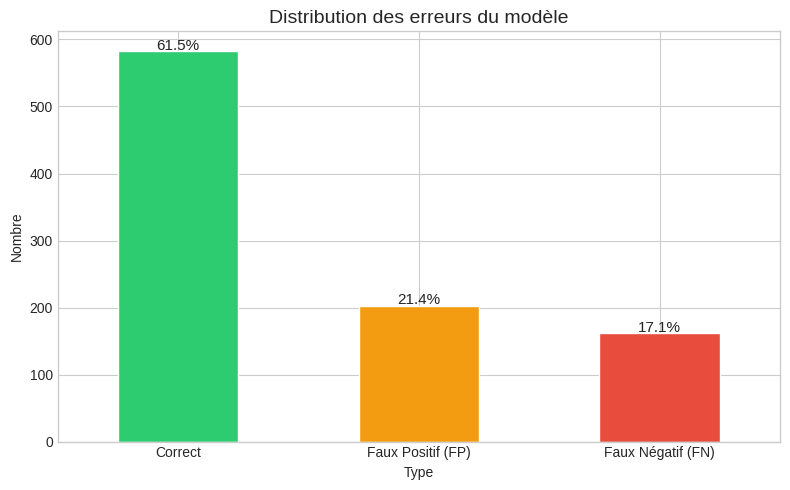


9.3 ANALYSE DES FAUX POSITIFS
----------------------------------------
🔍 Nombre de Faux Positifs: 203
   21.4% des prédictions

📊 Caractéristiques des Faux Positifs (moyennes):
   - age: FP=0.03 vs Moyenne=-0.00
   - booking_lead_days: FP=0.61 vs Moyenne=0.06
   - previous_no_shows: FP=0.19 vs Moyenne=0.01
   - distance_to_clinic_km: FP=0.22 vs Moyenne=0.04
   - waiting_time_minutes: FP=-0.00 vs Moyenne=-0.02

9.4 ANALYSE DES FAUX NÉGATIFS
----------------------------------------
🔍 Nombre de Faux Négatifs: 162
   17.1% des prédictions

📊 Caractéristiques des Faux Négatifs (moyennes):
   - age: FN=-0.08 vs Moyenne=-0.00
   - booking_lead_days: FN=-0.67 vs Moyenne=0.06
   - previous_no_shows: FN=-0.23 vs Moyenne=0.01
   - distance_to_clinic_km: FN=-0.08 vs Moyenne=0.04
   - waiting_time_minutes: FN=0.05 vs Moyenne=-0.02

9.5 DISTRIBUTION DES PROBABILITÉS PRÉDITES
----------------------------------------


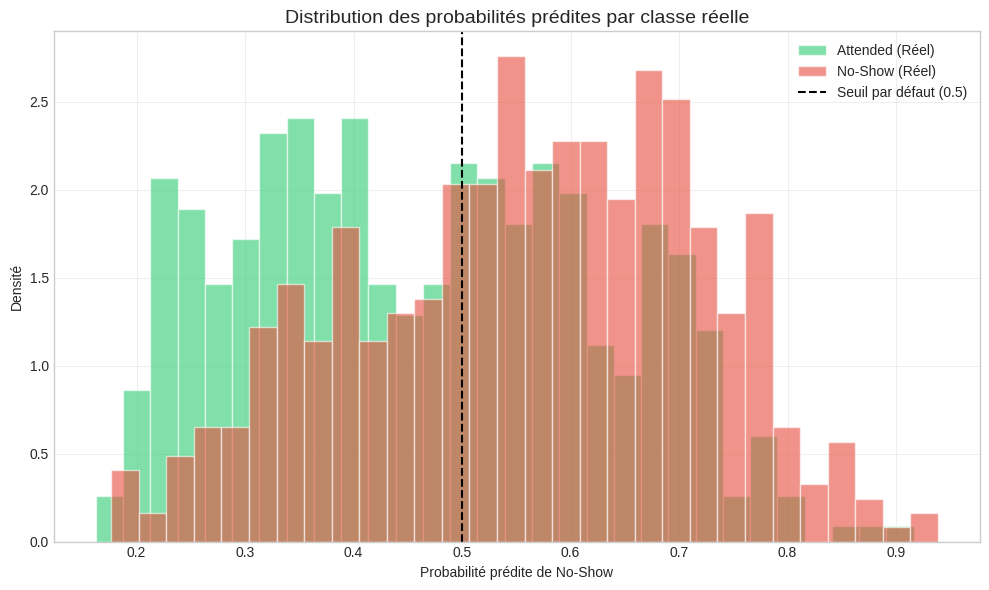


9.6 COURBE PRECISION-RECALL
----------------------------------------


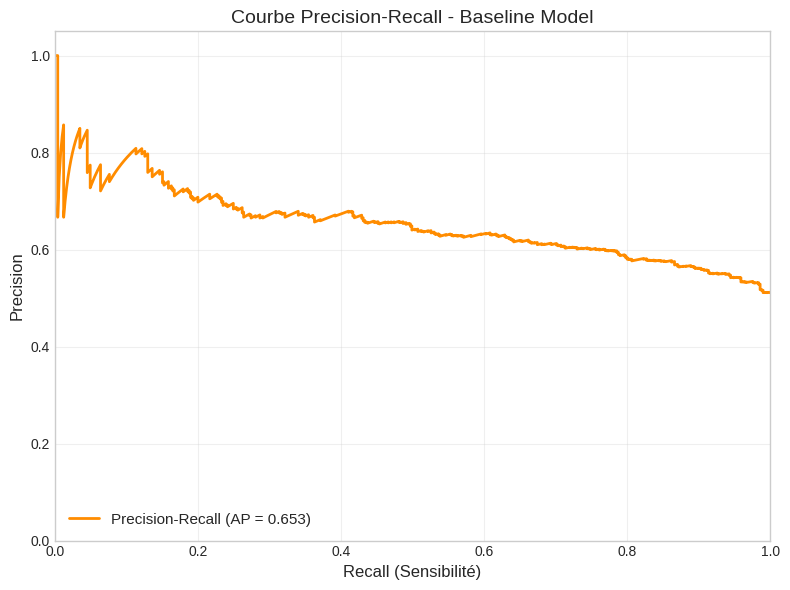


9.7 PERFORMANCE PAR SEUIL DE DÉCISION
----------------------------------------


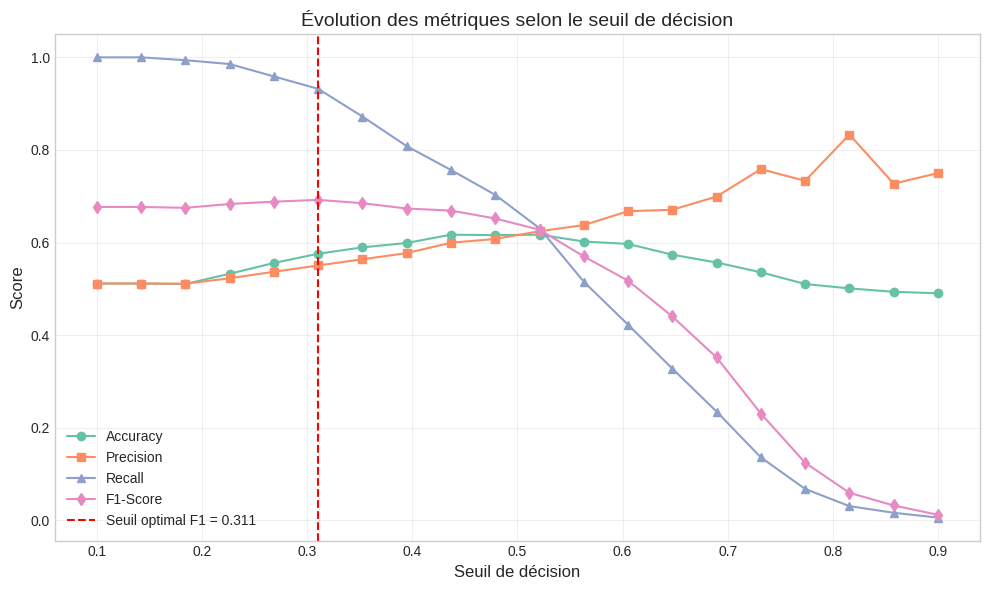


🔍 Seuil optimal pour F1-Score: 0.311
   Métriques à ce seuil:
   - Accuracy:  0.5759
   - Precision: 0.5505
   - Recall:    0.9320
   - F1-Score:  0.6922

9.8 ANALYSE DES ERREURS PAR GROUPE
----------------------------------------
📊 Performance par tranche d'âge:
   - 0-24: Accuracy=0.608 (472 patients)

9.9 ANALYSE DES ERREURS PAR TYPE DE RENDEZ-VOUS
----------------------------------------
📊 Performance par type de rendez-vous:
   - Follow-up: Accuracy=0.624 (279 patients)
   - General Consultation: Accuracy=0.648 (395 patients)
   - Diagnostic Test: Accuracy=0.565 (115 patients)
   - Specialist Consultation: Accuracy=0.553 (159 patients)

9.10 CALIBRATION DU MODÈLE
----------------------------------------


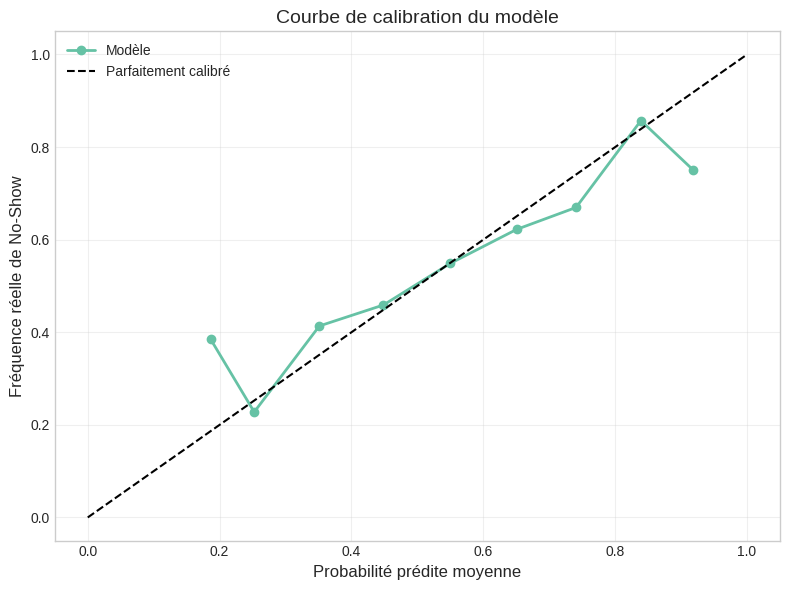


✅ ÉTAPE 9 TERMINÉE : ÉVALUATION APPROFONDIE

📋 RÉSUMÉ DE L'ÉTAPE 9:
   - ✅ Analyse des erreurs (FP/FN) effectuée
   - ✅ Distribution des probabilités analysée
   - ✅ Courbe Precision-Recall générée
   - ✅ Performance par seuil analysée
   - ✅ Performance par sous-groupes évaluée
   - ✅ Calibration du modèle vérifiée


In [30]:
# ============================================================
# ÉTAPE 9 : ÉVALUATION APPROFONDIE
# ============================================================
# Objectif : Analyser en détail les performances du modèle
# - Erreurs du modèle
# - Performance par sous-groupes
# - Analyse des faux positifs et faux négatifs
# - Courbes de précision/rappel
# ============================================================

print("\n" + "="*60)
print("ÉTAPE 9 : ÉVALUATION APPROFONDIE")
print("="*60)

# ------------------------------------------------------------------
# 9.1 Import des librairies supplémentaires
# ------------------------------------------------------------------

from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Librairies supplémentaires importées")

# ------------------------------------------------------------------
# 9.2 Analyse des erreurs
# ------------------------------------------------------------------

print("\n9.2 ANALYSE DES ERREURS")
print("-" * 40)

# Créer un DataFrame avec les résultats
results_df = X_test_scaled.copy()
results_df['y_true'] = y_test.values
results_df['y_pred'] = y_pred
results_df['y_pred_proba'] = y_pred_proba
results_df['error'] = y_test.values != y_pred

# Identifier les types d'erreurs
results_df['error_type'] = 'Correct'
results_df.loc[(results_df['y_true'] == 0) & (results_df['y_pred'] == 1), 'error_type'] = 'Faux Positif (FP)'
results_df.loc[(results_df['y_true'] == 1) & (results_df['y_pred'] == 0), 'error_type'] = 'Faux Négatif (FN)'

print(f"📊 Distribution des erreurs:")
print(results_df['error_type'].value_counts())

# Visualiser la distribution des erreurs
plt.figure(figsize=(8,5))
error_counts = results_df['error_type'].value_counts()
colors = {'Correct': '#2ecc71', 'Faux Positif (FP)': '#f39c12', 'Faux Négatif (FN)': '#e74c3c'}
error_counts.plot(kind='bar', color=[colors[x] for x in error_counts.index])
plt.title('Distribution des erreurs du modèle', fontsize=14)
plt.xlabel('Type')
plt.ylabel('Nombre')
plt.xticks(rotation=0)
for i, v in enumerate(error_counts):
    pct = (v / len(results_df)) * 100
    plt.text(i, v + 2, f'{pct:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 9.3 Analyse des Faux Positifs (FP)
# ------------------------------------------------------------------

print("\n9.3 ANALYSE DES FAUX POSITIFS")
print("-" * 40)

# Identifier les faux positifs (Attended prédits comme No-Show)
fp_mask = (results_df['y_true'] == 0) & (results_df['y_pred'] == 1)
fp_cases = results_df[fp_mask]

print(f"🔍 Nombre de Faux Positifs: {len(fp_cases)}")
print(f"   {len(fp_cases)/len(results_df)*100:.1f}% des prédictions")

if len(fp_cases) > 0:
    print("\n📊 Caractéristiques des Faux Positifs (moyennes):")
    fp_features = ['age', 'booking_lead_days', 'previous_no_shows',
                   'distance_to_clinic_km', 'waiting_time_minutes']
    for feature in fp_features:
        if feature in fp_cases.columns:
            mean_fp = fp_cases[feature].mean()
            mean_all = results_df[feature].mean()
            print(f"   - {feature}: FP={mean_fp:.2f} vs Moyenne={mean_all:.2f}")

# INTERPRÉTATION :
# - Les FP sont des patients qui se sont présentés mais que le modèle a classés comme No-Show
# - Cela peut être dû à des caractéristiques similaires aux vrais No-Show
# - Ces erreurs coûtent des rappels inutiles

# ------------------------------------------------------------------
# 9.4 Analyse des Faux Négatifs (FN)
# ------------------------------------------------------------------

print("\n9.4 ANALYSE DES FAUX NÉGATIFS")
print("-" * 40)

# Identifier les faux négatifs (No-Show prédits comme Attended)
fn_mask = (results_df['y_true'] == 1) & (results_df['y_pred'] == 0)
fn_cases = results_df[fn_mask]

print(f"🔍 Nombre de Faux Négatifs: {len(fn_cases)}")
print(f"   {len(fn_cases)/len(results_df)*100:.1f}% des prédictions")

if len(fn_cases) > 0:
    print("\n📊 Caractéristiques des Faux Négatifs (moyennes):")
    fn_features = ['age', 'booking_lead_days', 'previous_no_shows',
                   'distance_to_clinic_km', 'waiting_time_minutes']
    for feature in fn_features:
        if feature in fn_cases.columns:
            mean_fn = fn_cases[feature].mean()
            mean_all = results_df[feature].mean()
            print(f"   - {feature}: FN={mean_fn:.2f} vs Moyenne={mean_all:.2f}")

# INTERPRÉTATION :
# - Les FN sont des patients qui ont manqué mais que le modèle n'a pas détectés
# - C'est le pire cas : on rate des patients à risque
# - Ces erreurs coûtent des rendez-vous manqués

# ------------------------------------------------------------------
# 9.5 Distribution des probabilités prédites
# ------------------------------------------------------------------

print("\n9.5 DISTRIBUTION DES PROBABILITÉS PRÉDITES")
print("-" * 40)

# Visualiser la distribution des probabilités par classe réelle
plt.figure(figsize=(10,6))

# Attended (0)
plt.hist(results_df[results_df['y_true'] == 0]['y_pred_proba'],
         bins=30, alpha=0.6, label='Attended (Réel)', color='#2ecc71', density=True)

# No-Show (1)
plt.hist(results_df[results_df['y_true'] == 1]['y_pred_proba'],
         bins=30, alpha=0.6, label='No-Show (Réel)', color='#e74c3c', density=True)

plt.axvline(x=0.5, color='black', linestyle='--', label='Seuil par défaut (0.5)')
plt.xlabel('Probabilité prédite de No-Show')
plt.ylabel('Densité')
plt.title('Distribution des probabilités prédites par classe réelle', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Idéalement : les deux distributions devraient être bien séparées
# - Plus elles se chevauchent, plus le modèle a du mal à distinguer les classes
# - Le chevauchement autour de 0.5 explique les erreurs

# ------------------------------------------------------------------
# 9.6 Courbe Precision-Recall
# ------------------------------------------------------------------

print("\n9.6 COURBE PRECISION-RECALL")
print("-" * 40)

# Calculer la courbe Precision-Recall
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

# Visualiser
plt.figure(figsize=(8,6))
plt.plot(recall_curve, precision_curve, color='darkorange', lw=2,
         label=f'Precision-Recall (AP = {average_precision:.3f})')
plt.xlabel('Recall (Sensibilité)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall - Baseline Model', fontsize=14)
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Average Precision (AP) : moyenne de la précision sur tous les seuils
# - Plus AP est élevé, meilleur est le modèle
# - Cette courbe est particulièrement utile pour les classes déséquilibrées

# ------------------------------------------------------------------
# 9.7 Performance par seuil de décision
# ------------------------------------------------------------------

print("\n9.7 PERFORMANCE PAR SEUIL DE DÉCISION")
print("-" * 40)

# Évaluer les métriques pour différents seuils
thresholds_to_eval = np.linspace(0.1, 0.9, 20)
metrics_by_threshold = []

for thresh in thresholds_to_eval:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    metrics_by_threshold.append({
        'threshold': thresh,
        'accuracy': accuracy_score(y_test, y_pred_thresh),
        'precision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'recall': recall_score(y_test, y_pred_thresh, zero_division=0),
        'f1': f1_score(y_test, y_pred_thresh, zero_division=0)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

# Trouver le seuil optimal pour F1-Score
best_idx = metrics_df['f1'].idxmax()
best_threshold = metrics_df.loc[best_idx, 'threshold']

# Visualiser l'évolution des métriques
plt.figure(figsize=(10,6))
plt.plot(metrics_df['threshold'], metrics_df['accuracy'], 'o-', label='Accuracy')
plt.plot(metrics_df['threshold'], metrics_df['precision'], 's-', label='Precision')
plt.plot(metrics_df['threshold'], metrics_df['recall'], '^-', label='Recall')
plt.plot(metrics_df['threshold'], metrics_df['f1'], 'd-', label='F1-Score')

# Marquer le seuil optimal
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Seuil optimal F1 = {best_threshold:.3f}')

plt.xlabel('Seuil de décision', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Évolution des métriques selon le seuil de décision', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Afficher les métriques au seuil optimal
print(f"\n🔍 Seuil optimal pour F1-Score: {best_threshold:.3f}")
print(f"   Métriques à ce seuil:")
print(f"   - Accuracy:  {metrics_df.loc[best_idx, 'accuracy']:.4f}")
print(f"   - Precision: {metrics_df.loc[best_idx, 'precision']:.4f}")
print(f"   - Recall:    {metrics_df.loc[best_idx, 'recall']:.4f}")
print(f"   - F1-Score:  {metrics_df.loc[best_idx, 'f1']:.4f}")

# ------------------------------------------------------------------
# 9.8 Analyse des erreurs par groupe
# ------------------------------------------------------------------

print("\n9.8 ANALYSE DES ERREURS PAR GROUPE")
print("-" * 40)

# Analyser les performances par tranche d'âge
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['0-24', '25-34', '35-44', '45-54', '55-64', '65+']
results_df['age_group_analysis'] = pd.cut(results_df['age'], bins=age_bins, labels=age_labels)

print("📊 Performance par tranche d'âge:")
for age_group in age_labels:
    group_mask = results_df['age_group_analysis'] == age_group
    if group_mask.sum() > 0:
        group_accuracy = accuracy_score(
            results_df[group_mask]['y_true'],
            results_df[group_mask]['y_pred']
        )
        group_size = group_mask.sum()
        print(f"   - {age_group}: Accuracy={group_accuracy:.3f} ({group_size} patients)")

# ------------------------------------------------------------------
# 9.9 Analyse des erreurs par type de rendez-vous
# ------------------------------------------------------------------

print("\n9.9 ANALYSE DES ERREURS PAR TYPE DE RENDEZ-VOUS")
print("-" * 40)

# Récupérer les types de rendez-vous originaux
if 'appointment_type' in df_filtered.columns:
    results_df['appointment_type'] = df_filtered.loc[results_df.index, 'appointment_type']

    print("📊 Performance par type de rendez-vous:")
    for app_type in results_df['appointment_type'].unique():
        group_mask = results_df['appointment_type'] == app_type
        if group_mask.sum() > 0:
            group_accuracy = accuracy_score(
                results_df[group_mask]['y_true'],
                results_df[group_mask]['y_pred']
            )
            group_size = group_mask.sum()
            print(f"   - {app_type}: Accuracy={group_accuracy:.3f} ({group_size} patients)")
else:
    print("   ⚠️ 'appointment_type' non disponible dans les données")

# ------------------------------------------------------------------
# 9.10 Calibration du modèle
# ------------------------------------------------------------------

print("\n9.10 CALIBRATION DU MODÈLE")
print("-" * 40)

# La calibration mesure si les probabilités prédites sont fiables
# Exemple : si le modèle prédit 70% de probabilité, il devrait avoir raison dans 70% des cas

# Calculer la courbe de calibration
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

# Visualiser
plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Modèle')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Parfaitement calibré')
plt.xlabel('Probabilité prédite moyenne', fontsize=12)
plt.ylabel('Fréquence réelle de No-Show', fontsize=12)
plt.title('Courbe de calibration du modèle', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# - Si la courbe est en-dessous de la diagonale : le modèle est trop optimiste
# - Si la courbe est au-dessus : le modèle est trop pessimiste
# - Plus la courbe est proche de la diagonale, mieux le modèle est calibré

print("\n" + "="*60)
print("✅ ÉTAPE 9 TERMINÉE : ÉVALUATION APPROFONDIE")
print("="*60)

print("\n📋 RÉSUMÉ DE L'ÉTAPE 9:")
print("   - ✅ Analyse des erreurs (FP/FN) effectuée")
print("   - ✅ Distribution des probabilités analysée")
print("   - ✅ Courbe Precision-Recall générée")
print("   - ✅ Performance par seuil analysée")
print("   - ✅ Performance par sous-groupes évaluée")
print("   - ✅ Calibration du modèle vérifiée")

In [31]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Créer le répertoire 'figures' s'il n'existe pas
os.makedirs('figures', exist_ok=True)

# 1. Distribution de la cible
fig_td, ax_td = plt.subplots(figsize=(8,5))
df['appointment_outcome'].value_counts().plot(kind='bar', ax=ax_td)
ax_td.set_title('Distribution de appointment_outcome')
fig_td.savefig('figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.close(fig_td)

# 2. Matrice de confusion
fig_cm, ax_cm = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm)
ax_cm.set_title('Matrice de Confusion')
fig_cm.savefig('figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close(fig_cm)

# 3. Courbe ROC
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
ax_roc.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC (AUC = {roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Aléatoire (AUC = 0.5)')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('FPR'), ax_roc.set_ylabel('TPR')
ax_roc.set_title('Courbe ROC')
ax_roc.legend(loc="lower right", fontsize=11)
fig_roc.savefig('figures/roc_curve.png', dpi=300, bbox_inches='tight')
plt.close(fig_roc)

# 4. Importance des features
fig_fi, ax_fi = plt.subplots(figsize=(10,8))
ax_fi.barh(coef_df['Feature'], coef_df['Coefficient'])
ax_fi.set_title('Importance des Features')
fig_fi.savefig('figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.close(fig_fi)

# 5. Corrélations
fig_corr, ax_corr = plt.subplots(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=ax_corr)
ax_corr.set_title('Matrice de Corrélation')
fig_corr.savefig('figures/correlations.png', dpi=300, bbox_inches='tight')
plt.close(fig_corr)

# 6. Courbe Precision-Recall
fig_pr, ax_pr = plt.subplots(figsize=(8,6))
ax_pr.plot(recall_curve, precision_curve, color='darkorange', lw=2,
         label=f'Precision-Recall (AP = {average_precision:.3f})')
ax_pr.set_xlabel('Recall'), ax_pr.set_ylabel('Precision')
ax_pr.set_title('Courbe Precision-Recall')
ax_pr.legend(loc="lower left", fontsize=11)
fig_pr.savefig('figures/pr_curve.png', dpi=300, bbox_inches='tight')
plt.close(fig_pr)

# 7. Distribution des erreurs
fig_ed, ax_ed = plt.subplots(figsize=(8,5))
results_df['error_type'].value_counts().plot(kind='bar', ax=ax_ed)
ax_ed.set_title('Distribution des Erreurs')
fig_ed.savefig('figures/error_distribution.png', dpi=300, bbox_inches='tight')
plt.close(fig_ed)

# 8. Analyse des seuils
fig_ta, ax_ta = plt.subplots(figsize=(10,6))
ax_ta.plot(metrics_df['threshold'], metrics_df['accuracy'], 'o-', label='Accuracy')
ax_ta.plot(metrics_df['threshold'], metrics_df['precision'], 's-', label='Precision')
ax_ta.plot(metrics_df['threshold'], metrics_df['recall'], '^-', label='Recall')
ax_ta.plot(metrics_df['threshold'], metrics_df['f1'], 'd-', label='F1-Score')
ax_ta.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Seuil optimal F1 = {best_threshold:.3f}')
ax_ta.set_xlabel('Seuil'), ax_ta.set_ylabel('Score')
ax_ta.set_title('Performance selon le Seuil de Décision')
ax_ta.legend()
fig_ta.savefig('figures/threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.close(fig_ta)
